# 05. Кластеризация клиентов банка

Работаем с признаками, подготовленными в `04_preprocess_dataset.ipynb`: 9 стандартизованных признаков в четырёх
смысловых блоках — **финансы** (`log_income`, `log_savings_ratio`, `credit_sco`), **жизненный цикл** (`age`),
**отношения с банком** (`account_age_months`, `nums_card`, `nums_service`), **активность** (`sqrt_recency`, `tn_to_income`).

План:

1. Загрузка данных, общие выборки, метрики.
2. Набор функций для визуализации и интерпретации кластеров.
3. Взгляд на данные в 2D (PCA, t-SNE) — есть ли «видимые» кластеры.
4. Семейство K-means: подбор k, K-means (random init) vs K-means++, MiniBatch K-means, Bisecting K-means.
5. Иерархическая (агломеративная) кластеризация.
6. Плотностные методы: DBSCAN и HDBSCAN.
7. Спектральная кластеризация и BIRCH.
8. Сравнение алгоритмов и выбор финальной модели.
9. Проверка на отложенной выборке и стабильность.
10. Интерпретация кластеров.
11. Выводы.

**Как оцениваем качество.** Истинных меток нет, поэтому используем:
* внутренние метрики — *silhouette* (↑, от −1 до 1);
* устойчивость — ARI между разбиениями на бутстреп-подвыборках / разных запусках;
* внешние ориентиры, которые **не участвовали в обучении**: `cluster_group` (готовая сегментация банка) — через ARI/NMI,
  и `exit` (отток) — насколько кластеры различаются по доле ушедших;
* интерпретируемость — можно ли описать кластер бизнес-правилами.

In [1]:
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import (
    AgglomerativeClustering, Birch, BisectingKMeans, DBSCAN, HDBSCAN,
    KMeans, MiniBatchKMeans, SpectralClustering
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score, 
    normalized_mutual_info_score, 
    silhouette_score
)
from sklearn.neighbors import NearestNeighbors

import modules.plots as mplts
import modules.style as style
from modules.style import (
    GREEN, BLUE, YELLOW, GRAY, GRAY_LIGHT, WHITE,
    CHURN_COLOR, HIGHLIGHT_LINE, CLUSTER_PALETTE,
    SEQUENTIAL_CMAP, TRAIN_LINE, TEST_LINE, check_legend_handle, CHECK_MARKER
)

warnings.filterwarnings("ignore")
style.apply_default_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

In [2]:
DATA_DIR = Path("data/processed")
cfg = json.loads((DATA_DIR / "feature_config.json").read_text(encoding="utf-8"))
RANDOM_STATE = cfg["random_state"]
FEATURES = cfg["model_features"]

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
Z_COLS = cfg["model_columns"]           # z_<признак> — стандартизованные значения
X = train[Z_COLS].to_numpy()
X_test = test[Z_COLS].to_numpy()
print("train:", X.shape, "| test:", X_test.shape)
print("Признаки модели:", FEATURES)

train: (64000, 9) | test: (16000, 9)
Признаки модели: ['log_income', 'log_savings_ratio', 'credit_sco', 'age', 'account_age_months', 'nums_card', 'nums_service', 'sqrt_recency', 'tn_to_income']


### Общие подвыборки

Часть алгоритмов (иерархическая, спектральная, DBSCAN/HDBSCAN, t-SNE) на 64 000 объектах требует O(n²) памяти или
очень долго работает на одном ядре. Поэтому заводим **вложенные** случайные подвыборки train:

* `DENSE` (20 000) — для DBSCAN / HDBSCAN (плотностным методам нужно много точек, чтобы плотность оценивалась честно);
* `EVAL` (6 000) ⊂ `DENSE` — на ней обучаются тяжёлые алгоритмы и **на ней считаются метрики всех алгоритмов**, чтобы сравнение было честным;
* `VIS` (4 000) ⊂ `EVAL` — для 2D-визуализаций (t-SNE).

Алгоритмы, обучаемые на всём train (K-means, GMM, BIRCH), просто «отдают» метки на `EVAL`.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(len(X))
IDX_DENSE = perm[:20000]
IDX_EVAL = perm[:6000]
IDX_VIS = perm[:4000]
X_dense, X_eval, X_vis = X[IDX_DENSE], X[IDX_EVAL], X[IDX_VIS]
meta_eval = train.iloc[IDX_EVAL].reset_index(drop=True)

RESULTS = {}   # имя алгоритма -> словарь с метками на EVAL и метриками


def evaluate_labels(X_, labels, meta_=None):
    '''Внутренние и внешние метрики разбиения; шум (метка -1) исключается из внутренних метрик.'''
    labels = np.asarray(labels)
    mask = labels >= 0
    n_clusters = len(np.unique(labels[mask]))
    res = {"n_clusters": n_clusters, "noise_share": 1 - mask.mean()}
    if n_clusters >= 2:
        res["silhouette"] = silhouette_score(X_[mask], labels[mask])
    else:
        res.update(silhouette=np.nan)
    if meta_ is not None:
        res["ARI_cluster_group"] = adjusted_rand_score(meta_["cluster_group"], labels)
        res["NMI_cluster_group"] = normalized_mutual_info_score(meta_["cluster_group"], labels)
        rates = meta_.loc[mask, "exit"].groupby(labels[mask]).mean()
        res["exit_rate_min"] = rates.min()
        res["exit_rate_max"] = rates.max()
        # доля объяснённой «дисперсии оттока» кластерами (eta² из ANOVA) — насколько кластеры разводят отток
        y = meta_.loc[mask, "exit"].to_numpy()
        grp_mean = pd.Series(y).groupby(labels[mask]).transform("mean").to_numpy()
        res["exit_eta2"] = ((grp_mean - y.mean()) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    size = np.bincount(labels[mask]) if n_clusters else np.array([0])
    res["largest_cluster_share"] = size.max() / len(labels)
    return res


def register(name, labels_eval, fit_on, seconds, family):
    RESULTS[name] = {
        "labels": np.asarray(labels_eval), 
        "fit_on": fit_on, 
        "time_s": seconds, 
        "family": family,
        **evaluate_labels(X_eval, labels_eval, meta_eval)
    }

## 2. Функции визуализации и интерпретации

Все графики собраны в функции, чтобы одинаково анализировать результат любого алгоритма:

| Функция | Что показывает |
|---|---|
| `plot_embedding` | точки в 2D (PCA / t-SNE), раскрашенные по кластерам; шум — серым |
| `plot_algorithms_grid` | сетка 2D-проекций для нескольких алгоритмов |
| `plot_k_selection` | метрики выбора числа кластеров (локоть, silhouette, CH, DB, устойчивость) |
| `plot_silhouette_diagram` | «ножи» silhouette по кластерам — видно плохо отделённые кластеры |
| `plot_cluster_sizes` | размеры кластеров |
| `cluster_profile` / `plot_profile_heatmap` | средние стандартизованных признаков по кластерам (z-score) |
| `plot_radar` | «паутинка» профилей кластеров |
| `plot_numeric_by_cluster` | распределения исходных (немасштабированных) признаков по кластерам |
| `plot_categorical_by_cluster` | состав кластеров по категориальным признакам |
| `plot_churn_by_cluster` | доля оттока в кластерах |
| `plot_crosstab` | сопоставление двух разбиений (например, с `cluster_group`) |
| `surrogate_tree` | правила «если–то», описывающие кластеры (дерево решений поверх меток) |
| `cluster_report` | всё вместе для одного разбиения |

## 3. Как данные выглядят в 2D

Прежде чем что-то кластеризовать, посмотрим на проекции: PCA (линейная, сохраняет глобальную геометрию) и t-SNE
(нелинейная, сохраняет локальные окрестности). Раскрасим точки по внешним меткам — `exit` и `cluster_group`.

t-SNE: 32.9 c; PCA(2) объясняет 48.0% дисперсии


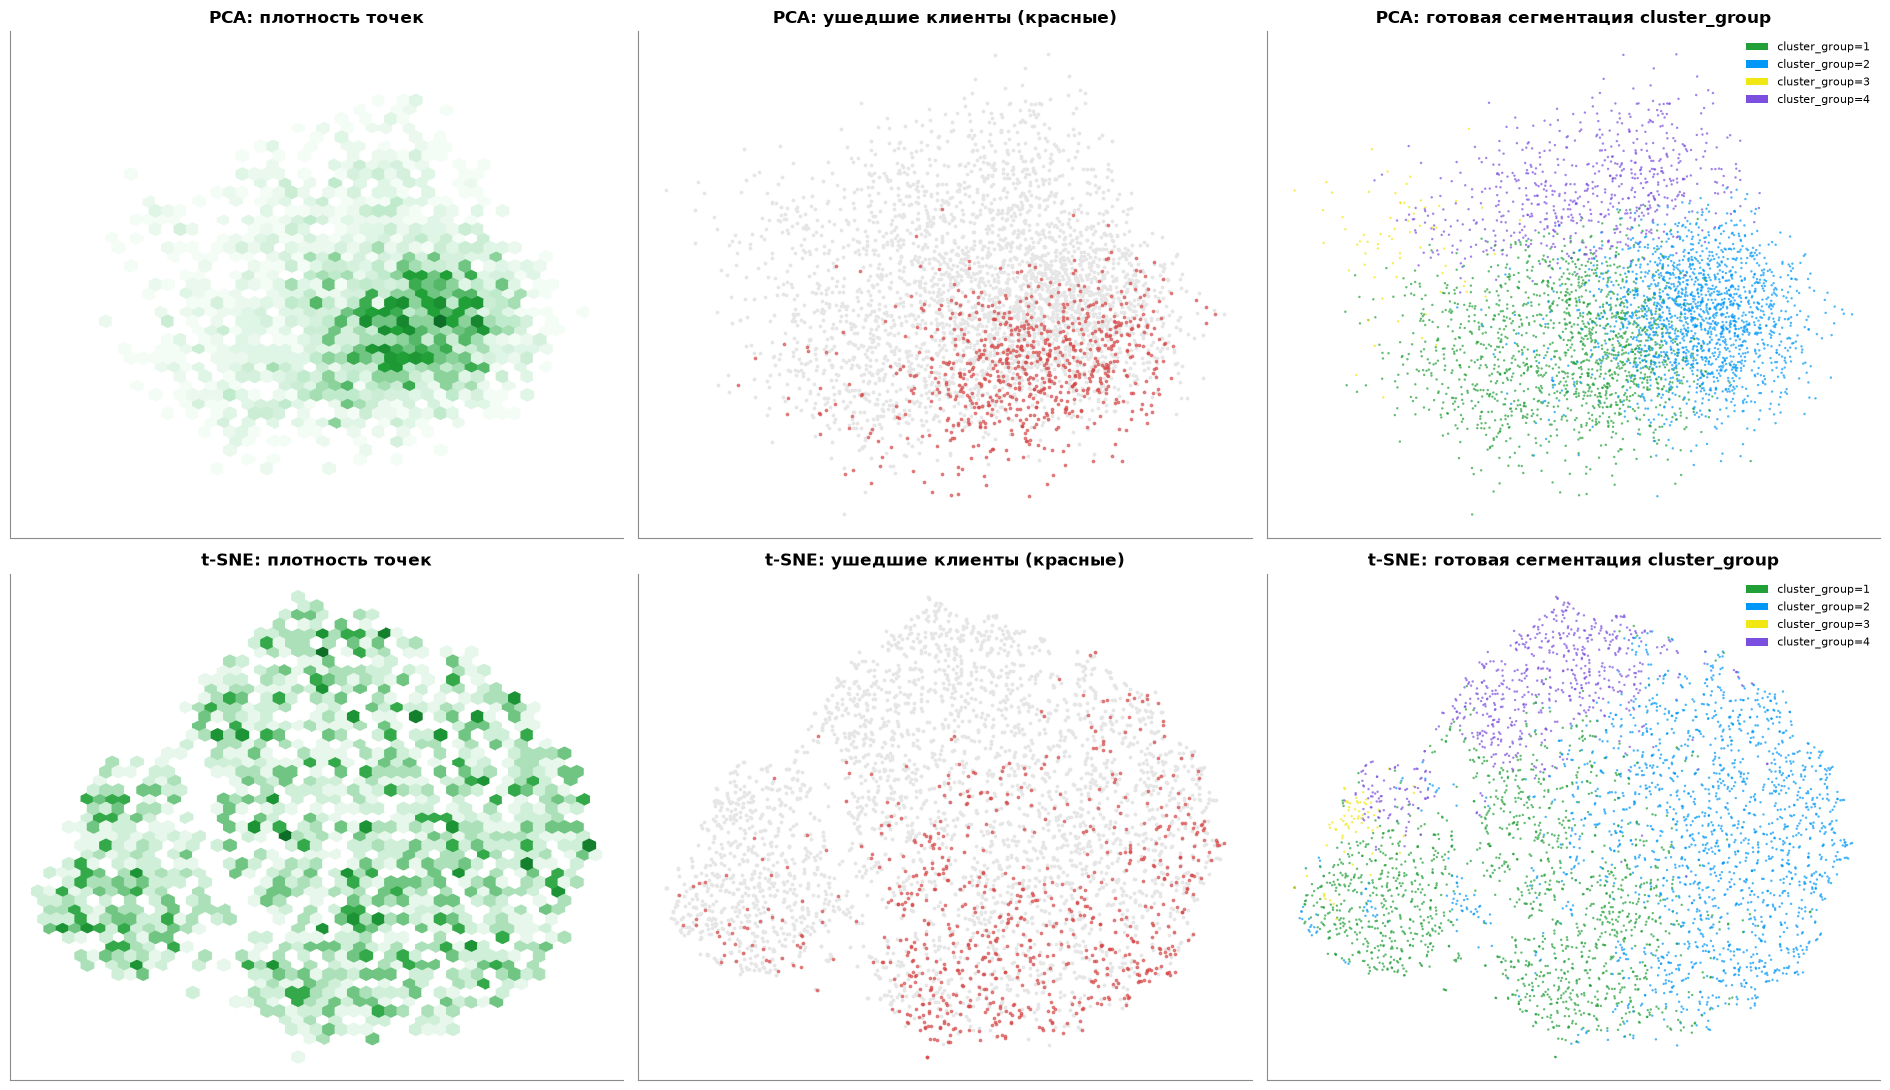

In [4]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X)
emb_pca = pca2.transform(X_vis)
t0 = time.time()
emb_tsne = TSNE(n_components=2, perplexity=40, init="pca", random_state=RANDOM_STATE).fit_transform(X_vis)
print(f"t-SNE: {time.time() - t0:.1f} c; PCA(2) объясняет {pca2.explained_variance_ratio_.sum():.1%} дисперсии")

meta_vis = train.iloc[IDX_VIS].reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for row, (emb, nm) in enumerate([(emb_pca, "PCA"), (emb_tsne, "t-SNE")]):
    axes[row, 0].hexbin(emb[:, 0], emb[:, 1], gridsize=45, cmap=SEQUENTIAL_CMAP, mincnt=1)
    axes[row, 0].set_title(f"{nm}: плотность точек"); axes[row, 0].grid(False)
    ex = meta_vis["exit"].to_numpy()
    axes[row, 1].scatter(emb[ex == 0, 0], emb[ex == 0, 1], s=3, c=GRAY_LIGHT)
    axes[row, 1].scatter(emb[ex == 1, 0], emb[ex == 1, 1], s=3, c=CHURN_COLOR, alpha=0.6)
    axes[row, 1].set_title(f"{nm}: ушедшие клиенты (красные)"); axes[row, 1].grid(False)
    mplts.plot_embedding(
        emb, meta_vis["cluster_group"].to_numpy() - 1, ax=axes[row, 2], s=3,
        names={i: f"cluster_group={i + 1}" for i in range(4)}, 
        title=f"{nm}: готовая сегментация cluster_group"
    )
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

**Что видно.**
* В проекции PCA данные образуют **одно сплошное облако** без явных «провалов» плотности — естественных, чётко
  отделённых групп нет.
* t-SNE, который усиливает локальную структуру, отделяет небольшую «долю» слева; остальное — единый массив неактивных клиентов с «зернистостью» от дискретных признаков.
* Ушедшие клиенты не рассеяны случайно, а сосредоточены в определённых областях (внизу), а готовые группы `cluster_group`
  занимают разные области, — значит, разумная сегментация сможет разделить клиентов по риску оттока.

**Следствие для выбора алгоритмов:** здесь стоит ожидать, что *разбивающие* методы (K-means, Ward) дадут полезную
**сегментацию континуума**, а *плотностные* (DBSCAN, HDBSCAN), которые ищут области высокой плотности, разделённые
разрежёнными промежутками, будут испытывать трудности. Проверим это.

## 4. Семейство K-means

### 4.1 Подбор числа кластеров

Для k = 2…10 обучаем K-means++ на всём train и считаем:
* **inertia** (сумма квадратов расстояний до центроидов) — ищем «локоть»;
* **silhouette** на `EVAL`;
* **устойчивость** — 5 раз обучаем на случайной половине train и считаем средний ARI между разбиениями `EVAL`.
  Если k «правильное», решение воспроизводится; если нет — центроиды «прыгают» между равноценными конфигурациями.

In [5]:
K_RANGE = range(2, 11)
rows = []
t0 = time.time()
for k in K_RANGE:
    km = KMeans(
        n_clusters=k, init="k-means++", 
        n_init=4, random_state=RANDOM_STATE
    ).fit(X)
    lab = km.labels_[IDX_EVAL]
    boot = []
    for b in range(5):
        idx = rng.choice(len(X), len(X) // 2, replace=False)
        boot.append(KMeans(n_clusters=k, n_init=2, random_state=b).fit(X[idx]).predict(X_eval))
    stab = np.mean([adjusted_rand_score(boot[i], boot[j]) for i in range(5) for j in range(i + 1, 5)])
    rows.append({
        "k": k, 
        "inertia": km.inertia_, 
        "silhouette": silhouette_score(X_eval, lab),
        "stability_ari": stab,
        "ARI_cluster_group": adjusted_rand_score(meta_eval["cluster_group"], lab)
    })
k_metrics = pd.DataFrame(rows).set_index("k")
print(f"Перебор k: {time.time() - t0:.1f} c", end=' ')
print(f"«локоть» по Kneedle: k = {mplts.knee_point(k_metrics.index, k_metrics['inertia']):.0f}")
k_metrics.round(3)

Перебор k: 32.1 c «локоть» по Kneedle: k = 4


,inertia,silhouette,stability_ari,ARI_cluster_group
k,,,,
2,473275.627,0.183,0.959,0.277
3,408555.212,0.182,0.979,0.302
4,369242.577,0.143,0.969,0.391
5,347112.438,0.135,0.965,0.326
6,330649.493,0.129,0.954,0.282
7,317871.603,0.126,0.941,0.237
8,307764.698,0.121,0.725,0.217
9,298611.649,0.114,0.715,0.211
10,290902.239,0.108,0.669,0.185


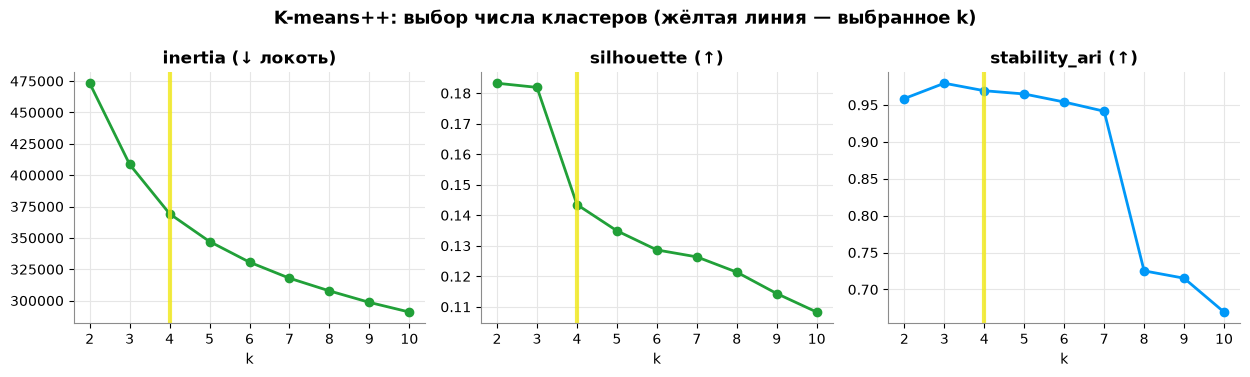

In [6]:
K_FINAL = 4
mplts.plot_k_selection(
    k_metrics.drop(columns="ARI_cluster_group"), chosen_k=K_FINAL,
    title="K-means++: выбор числа кластеров (жёлтая линия — выбранное k)"
)
plt.show()

**Выбор k = 4.** Метрики не дают однозначного ответа:

* **silhouette** максимален при k = 2–3 (≈ 0.18), при k = 4 падает до ≈ 0.14 и дальше медленно снижается; абсолютные
  значения невелики — кластеры перекрываются, как и ожидалось по 2D-проекциям;
* **локоть** inertia (Kneedle) — k = 4;
* **устойчивость** высокая (ARI ≥ 0.94) до k = 7 и **резко падает при k ≥ 8** — дальше кластеры «плавают»;
* при k = 4 **максимально согласие** с независимой сегментацией банка `cluster_group` (ARI ≈ 0.39).

k = 4 — «локоть», устойчивое и лучше всего согласованное с внешним эталоном решение. Его используем для всех
алгоритмов, где k задаётся явно, — так их удобно сравнивать между собой.

### 4.2 K-means (случайная инициализация) vs K-means++

Классический K-means инициализирует центроиды случайными точками и может застрять в плохом
локальном минимуме. **K-means++** выбирает начальные центроиды последовательно, с вероятностью ∝ квадрату расстояния до
уже выбранных, — центры сразу «разнесены» по данным. Сравним по 20 запусков каждого варианта с `n_init=1`
(одна инициализация на запуск — чтобы увидеть разброс, который обычно прячет `n_init`).

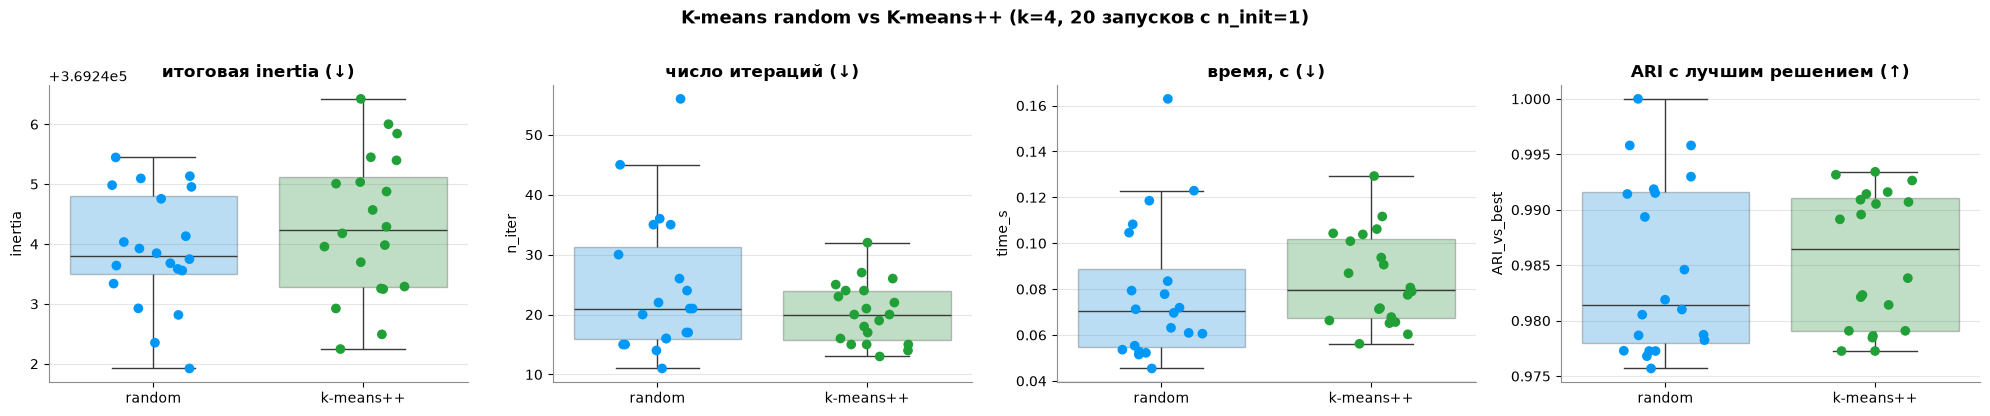

inertia                                n_iter                 time_s                     ARI_vs_best                     
                 mean    std         min         max   mean     std min max   mean   std    min    max        mean    std    min    max
init                                                                                                                                   
k-means++  369244.308  1.191  369242.246  369246.424   20.3   5.069  13  32  0.084  0.02  0.056  0.129       0.986  0.006  0.977  0.993
random     369243.893  0.961  369241.921  369245.446   24.6  11.650  11  56  0.078  0.03  0.045  0.163       0.985  0.008  0.976  1.000

In [7]:
runs = []
for init in ["random", "k-means++"]:
    for seed in range(20):
        t0 = time.time()
        km = KMeans(n_clusters=K_FINAL, init=init, n_init=1, random_state=seed).fit(X)
        runs.append({
            "init": init, "seed": seed, 
            "inertia": km.inertia_, 
            "n_iter": km.n_iter_,
            "time_s": time.time() - t0, 
            "labels": km.labels_[IDX_EVAL]
        })
runs = pd.DataFrame(runs)
best = runs.loc[runs["inertia"].idxmin(), "labels"]
runs["ARI_vs_best"] = runs["labels"].apply(lambda l: adjusted_rand_score(best, l))

fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
for ax, col, ttl in zip(
    axes, ["inertia", "n_iter", "time_s", "ARI_vs_best"],
    ["итоговая inertia (↓)", "число итераций (↓)", "время, с (↓)", "ARI с лучшим решением (↑)"]
):
    sns.stripplot(data=runs, x="init", y=col, ax=ax, palette=[BLUE, GREEN], size=7, jitter=0.2)
    sns.boxplot(data=runs, x="init", y=col, ax=ax, palette=[BLUE, GREEN], boxprops=dict(alpha=0.3), fliersize=0)
    ax.set_title(ttl); ax.set_xlabel("")
fig.suptitle(f"K-means random vs K-means++ (k={K_FINAL}, 20 запусков с n_init=1)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()
runs.groupby("init")[["inertia", "n_iter", "time_s", "ARI_vs_best"]].agg(["mean", "std", "min", "max"]).round(3)

**Вывод.** На этих данных оба варианта в итоге приходят к очень близким решениям (разница inertia < 0.001 %,
ARI с лучшим решением ≈ 0.985 у обоих): при k = 4 у функции потерь немного «хороших» минимумов. Разница — в пути:
K-means++ сходится **стабильнее** — меньше итераций в среднем и вдвое меньший разброс (максимум ~30 итераций против
~55 у случайной инициализации), потому что стартовые центры уже разнесены по данным. На данных с более выраженной
структурой (много маленьких кластеров) случайная инициализация чаще застревает в плохих минимумах — поэтому K-means++
является стандартом.

In [8]:
t0 = time.time()
km_rand = KMeans(n_clusters=K_FINAL, init="random", n_init=10, random_state=RANDOM_STATE).fit(X)
register("K-means (random)", km_rand.labels_[IDX_EVAL], "весь train", time.time() - t0, "центроидные")

t0 = time.time()
kmeans = KMeans(n_clusters=K_FINAL, init="k-means++", n_init=10, random_state=RANDOM_STATE).fit(X)
register("K-means++", kmeans.labels_[IDX_EVAL], "весь train", time.time() - t0, "центроидные")

### 4.3 MiniBatch K-means и Bisecting K-means

* **MiniBatch K-means** обновляет центроиды по случайным мини-батчам — в разы быстрее на больших данных ценой
  небольшой потери качества.
* **Bisecting K-means** — «нисходящая иерархическая» версия: начинает с одного кластера и каждый раз делит на два
  самый большой (или с наибольшей SSE) кластер. Даёт иерархию и обычно более сбалансированные кластеры.

In [9]:
t0 = time.time()
mbk = MiniBatchKMeans(n_clusters=K_FINAL, batch_size=2048, n_init=10, random_state=RANDOM_STATE).fit(X)
register("MiniBatch K-means", mbk.labels_[IDX_EVAL], "весь train", time.time() - t0, "центроидные")

for strategy in ["biggest_inertia", "largest_cluster"]:
    t0 = time.time()
    bkm = BisectingKMeans(n_clusters=K_FINAL, bisecting_strategy=strategy, n_init=3,
                          random_state=RANDOM_STATE).fit(X)
    register(f"Bisecting K-means ({strategy.split('_')[0]})", bkm.labels_[IDX_EVAL], "весь train",
             time.time() - t0, "центроидные")

print(f"\nInertia: K-means++ {kmeans.inertia_:,.0f} | MiniBatch {mbk.inertia_:,.0f} "
      f"(+{mbk.inertia_ / kmeans.inertia_ - 1:.2%})")
print("ARI MiniBatch vs K-means++:", round(adjusted_rand_score(kmeans.labels_, mbk.labels_), 3))


Inertia: K-means++ 369,242 | MiniBatch 370,101 (+0.23%)
ARI MiniBatch vs K-means++: 0.866


## 5. Иерархическая (агломеративная) кластеризация

Агломеративная кластеризация начинает с отдельных объектов и последовательно сливает ближайшие кластеры.
Результат — дендрограмма, которую можно «разрезать» на любом уровне. Ключевой параметр — **способ связи** (linkage):

* **ward** — сливает пару, минимально увеличивающую внутрикластерную дисперсию (близок к K-means);
* **complete** — расстояние между кластерами = максимум попарных расстояний (компактные кластеры);
* **average** — среднее попарных расстояний;
* **single** — минимум попарных расстояний (склонен к «цепочкам»).

Память O(n²) → обучаем на `EVAL` (6 000 объектов).

Ward linkage на 6000 объектах: 2.2 c


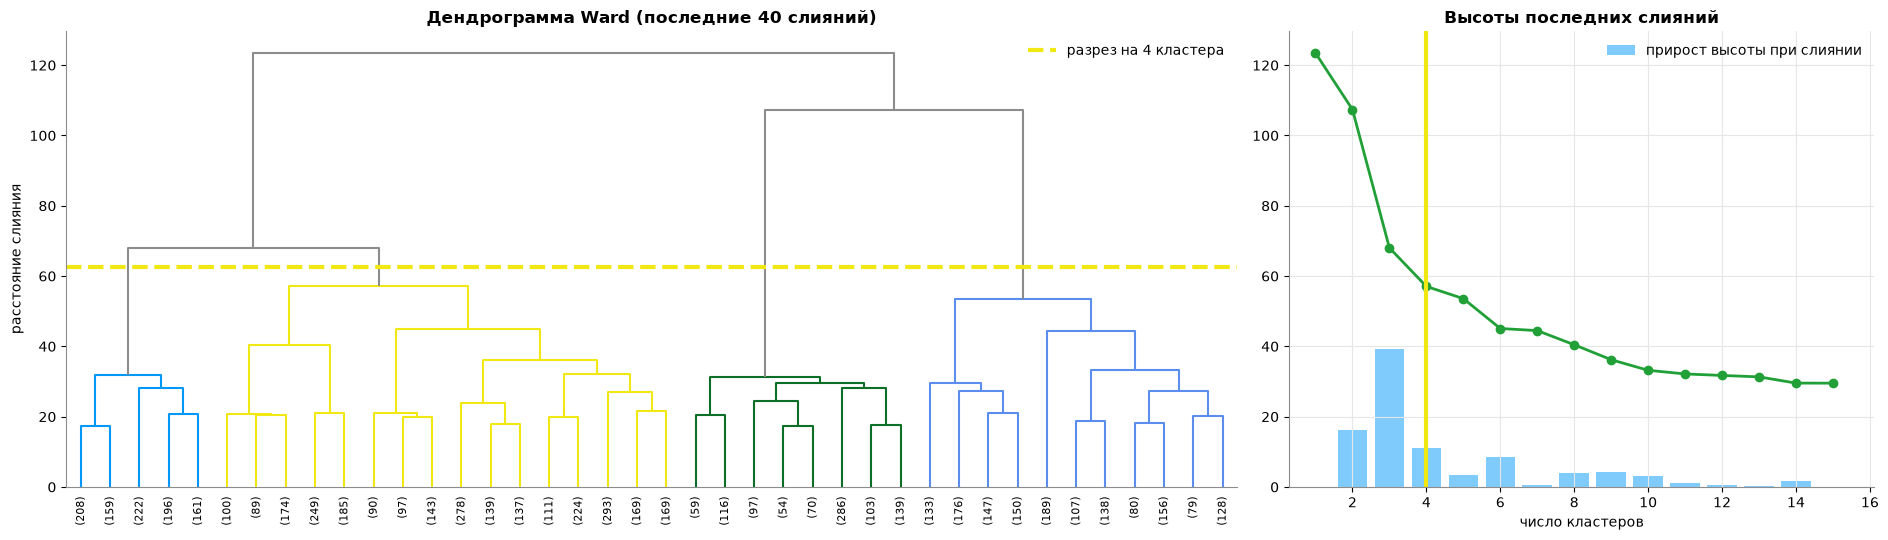

In [10]:
t0 = time.time()
Z = linkage(X_eval, method="ward")
print(f"Ward linkage на {len(X_eval)} объектах: {time.time() - t0:.1f} c")

fig, axes = plt.subplots(1, 2, figsize=(19, 5.5), gridspec_kw={"width_ratios": [2, 1]})
cut = Z[-K_FINAL + 1, 2] * 0.5 + Z[-K_FINAL, 2] * 0.5   # высота разреза между 3-м и 4-м слиянием с конца
dendrogram(Z, truncate_mode="lastp", p=40, ax=axes[0], color_threshold=cut,
           above_threshold_color=GRAY, show_leaf_counts=True, leaf_rotation=90)
axes[0].axhline(cut, color=HIGHLIGHT_LINE, lw=3, ls="--", label=f"разрез на {K_FINAL} кластера")
axes[0].set_title("Дендрограмма Ward (последние 40 слияний)"); axes[0].legend(); axes[0].grid(False)
axes[0].set_ylabel("расстояние слияния")

heights = Z[-15:, 2][::-1]
axes[1].plot(range(1, 16), heights, "o-", color=GREEN, lw=2)
axes[1].bar(range(2, 16), -np.diff(heights), color=BLUE, alpha=0.5, label="прирост высоты при слиянии")
axes[1].axvline(K_FINAL, color=HIGHLIGHT_LINE, lw=3)
axes[1].set_xlabel("число кластеров"); axes[1].set_title("Высоты последних слияний"); axes[1].legend()
fig.tight_layout()
plt.show()

На дендрограмме видны крупные «скачки» высоты при переходе от 4 к 3 и от 3 к 2 кластерам: объединять эти группы
«дорого». Разрез на 4 кластера согласуется с выбором для K-means.

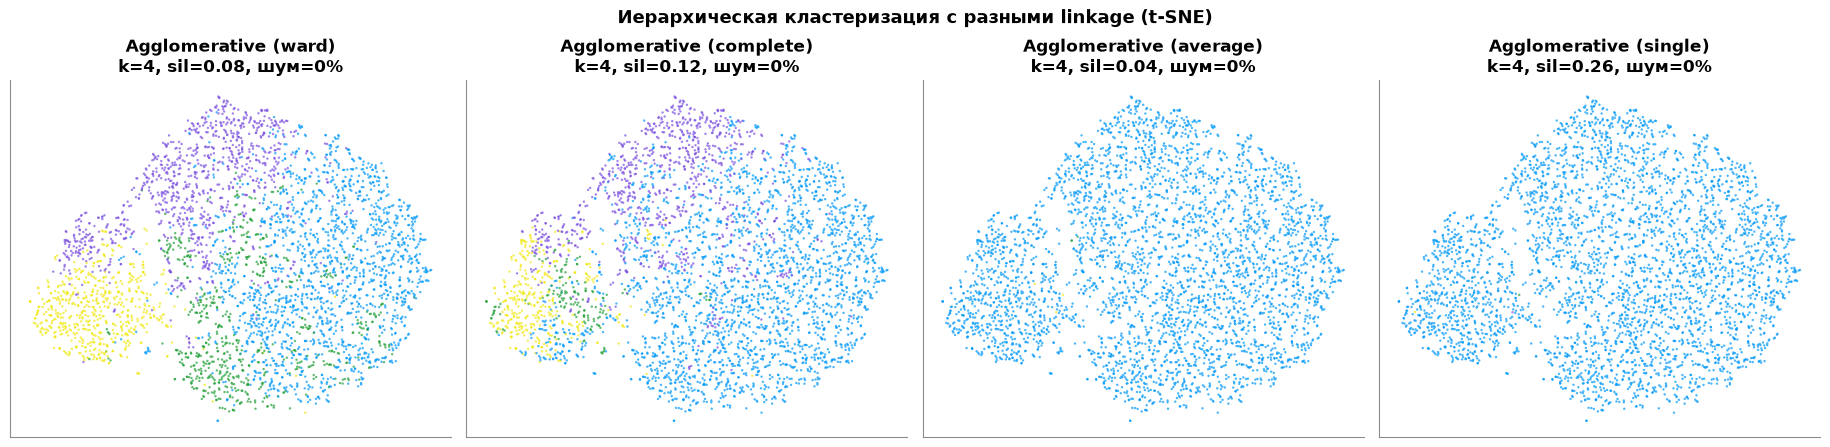

,кластер_0,кластер_1,кластер_2,кластер_3
ward,2647,1483,924,946
complete,3844,552,1379,225
average,8,5988,1,3
single,5997,1,1,1


In [11]:
for link in ["ward", "complete", "average", "single"]:
    t0 = time.time()
    lab = AgglomerativeClustering(n_clusters=K_FINAL, linkage=link).fit_predict(X_eval)
    register(f"Agglomerative ({link})", lab, "EVAL 6k", time.time() - t0, "иерархические")

fig = mplts.plot_algorithms_grid(
    [f"Agglomerative ({l})" for l in ["ward", "complete", "average", "single"]], 
    emb_tsne, reference="K-means++", labels_source=RESULTS
)
fig.suptitle("Иерархическая кластеризация с разными linkage (t-SNE)", fontsize=13, fontweight="bold", y=1.03)
plt.show()
pd.DataFrame({l: np.bincount(RESULTS[f"Agglomerative ({l})"]["labels"], minlength=K_FINAL)
              for l in ["ward", "complete", "average", "single"]}).T.add_prefix("кластер_")

**Вывод.** Только **Ward** даёт сбалансированные содержательные группы. `complete` даёт заметно менее сбалансированное разбиение, а `average` и
`single` вырождаются в один гигантский кластер + несколько точек-одиночек (эффект «цепочки» в сплошном облаке). Обратите внимание: у `single` silhouette может оказаться формально высоким — метрика «хвалит» отделение
нескольких далёких точек, хотя разбиение бесполезно. Поэтому метрики всегда смотрим вместе с размерами кластеров.

## 7. Плотностные методы: DBSCAN и HDBSCAN

### 7.1 DBSCAN

DBSCAN объединяет точки, у которых в радиусе `eps` не меньше `min_samples` соседей, и помечает остальное шумом.
Эвристики подбора: `min_samples ≈ 2 × число признаков = 18`, `eps` — по «колену» графика расстояния до
`min_samples`-го соседа (k-distance plot).

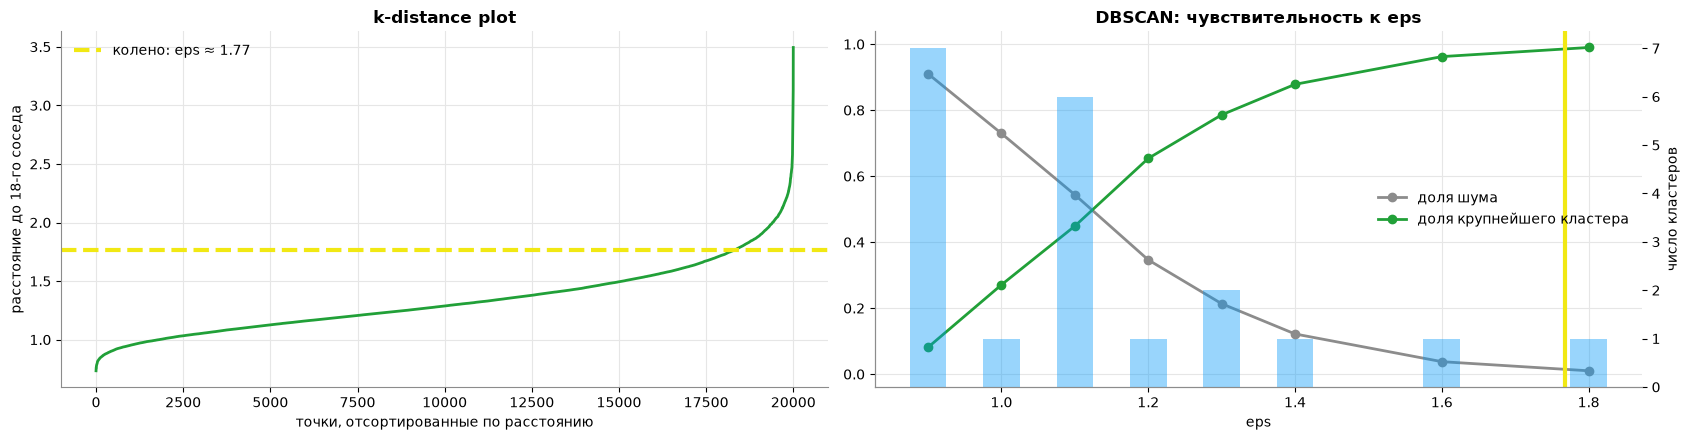

,eps,n_clusters,noise_share,largest_cluster_share,second_cluster_size
0,0.9,7,0.910,0.081,65
1,1.0,1,0.729,0.271,0
2,1.1,6,0.544,0.449,61
3,1.2,1,0.346,0.654,0
4,1.3,2,0.213,0.786,17
5,1.4,1,0.122,0.878,0
6,1.6,1,0.038,0.962,0
7,1.8,1,0.010,0.990,0


In [12]:
MIN_SAMPLES = 2 * len(FEATURES)
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_dense)
kdist = np.sort(nn.kneighbors(X_dense)[0][:, -1])
eps_knee = mplts.knee_point(np.arange(len(kdist)), kdist)
eps_knee = kdist[int(eps_knee)]

eps_grid = [0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.6, 1.8]
db_rows = []
for eps in eps_grid:
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X_dense)
    sizes = np.bincount(lab[lab >= 0]) if (lab >= 0).any() else np.array([0])
    db_rows.append({"eps": eps, "n_clusters": lab.max() + 1, "noise_share": (lab == -1).mean(),
                    "largest_cluster_share": sizes.max() / len(lab), "second_cluster_size": np.sort(sizes)[-2] if len(sizes) > 1 else 0})
db_grid = pd.DataFrame(db_rows)

fig, axes = plt.subplots(1, 2, figsize=(17, 4.5))
axes[0].plot(kdist, color=GREEN, lw=2)
axes[0].axhline(eps_knee, color=HIGHLIGHT_LINE, lw=3, ls="--", label=f"колено: eps ≈ {eps_knee:.2f}")
axes[0].set_xlabel("точки, отсортированные по расстоянию"); axes[0].set_ylabel(f"расстояние до {MIN_SAMPLES}-го соседа")
axes[0].set_title("k-distance plot"); axes[0].legend()
axes[1].plot(db_grid["eps"], db_grid["noise_share"], "o-", color=GRAY, lw=2, label="доля шума")
axes[1].plot(db_grid["eps"], db_grid["largest_cluster_share"], "o-", color=GREEN, lw=2, label="доля крупнейшего кластера")
ax2 = axes[1].twinx()
ax2.grid(False)
ax2.bar(db_grid["eps"], db_grid["n_clusters"], width=0.05, color=BLUE, alpha=0.4, label="число кластеров")
ax2.set_ylabel("число кластеров")
axes[1].axvline(eps_knee, color=HIGHLIGHT_LINE, lw=3)
axes[1].set_xlabel("eps"); axes[1].set_title("DBSCAN: чувствительность к eps"); axes[1].legend(loc="center right")
fig.tight_layout()
plt.show()
db_grid.round(3)

In [15]:
# eps по «колену» и компромиссное eps, при котором появляется хоть какая-то структура
for eps in [round(eps_knee, 2), 1.1]:
    t0 = time.time()
    db_labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X_dense)
    register(f"DBSCAN (eps={eps})", db_labels[:len(IDX_EVAL)], "DENSE 20k", time.time() - t0, "плотностные")

**Вывод.** У DBSCAN нет «золотой середины»: при малом `eps` почти всё — шум, при большом — одна гигантская компонента,
в которую сливается всё облако. Промежуточные значения дают один большой кластер + несколько «островков» из десятков
точек. Это прямое следствие того, что в данных **нет областей высокой плотности, разделённых разрежёнными
промежутками** — плотность меняется плавно, и DBSCAN с одним глобальным порогом плотности не может разрезать
континуум. Результат не бесполезен: точки-шум на «колене» — это клиенты с редким сочетанием признаков (кандидаты в аномалии).

### 7.2 HDBSCAN

HDBSCAN строит иерархию DBSCAN-разбиений по всем `eps` сразу и выбирает наиболее «устойчивые» кластеры —
не нужно подбирать `eps`, остаются `min_cluster_size` и `min_samples`. Он умеет находить кластеры разной плотности.

In [16]:
hdb_rows = []
for mcs in [30, 50, 100, 300, 1000]:
    for single in [False, True]:
        t0 = time.time()
        h = HDBSCAN(
            min_cluster_size=mcs, min_samples=10, 
            allow_single_cluster=single, copy=True
        ).fit(X_dense)
        lab = h.labels_
        sizes = np.bincount(lab[lab >= 0]) if (lab >= 0).any() else np.array([0])
        hdb_rows.append({
            "min_cluster_size": mcs, 
            "allow_single_cluster": single, 
            "n_clusters": lab.max() + 1,
            "noise_share": (lab == -1).mean(), 
            "sizes": sorted(sizes.tolist(), reverse=True)[:6],
            "time_s": time.time() - t0
        })
pd.DataFrame(hdb_rows).round(3)

,min_cluster_size,allow_single_cluster,n_clusters,noise_share,sizes,time_s
0,30,False,2,0.659,"[6744, 82]",8.030
1,30,True,1,0.659,[6826],10.123
2,50,False,2,0.659,"[6744, 82]",7.304
3,50,True,1,0.659,[6826],9.357
4,100,False,2,0.949,"[908, 107]",7.320
5,100,True,1,0.949,[1015],9.660
6,300,False,0,1.000,[0],7.639
7,300,True,1,0.985,[300],9.629
8,1000,False,0,1.000,[0],7.401
9,1000,True,1,0.949,[1015],9.722


HDBSCAN подтверждает вывод DBSCAN: при `min_cluster_size ≥ 300` иерархия плотности не содержит устойчивых «ветвей» —
алгоритм либо помечает всё шумом, либо (с `allow_single_cluster=True`) выделяет одно «ядро». При маленьком
`min_cluster_size` он находит два плотных сгустка, а 2/3 клиентов считает шумом. Посмотрим, что это за сгустки.

In [ ]:
t0 = time.time()
hdb = HDBSCAN(min_cluster_size=50, min_samples=10, copy=True).fit(X_dense)
hdb_labels = hdb.labels_
register("HDBSCAN (mcs=50)", hdb_labels[:len(IDX_EVAL)], "DENSE 20k", time.time() - t0, "плотностные")

meta_dense = train.iloc[IDX_DENSE].reset_index(drop=True)
micro = meta_dense[hdb_labels >= 0].assign(hdb=hdb_labels[hdb_labels >= 0])
micro_prof = micro.groupby("hdb").agg(
    size=("id", "size"), 
    income_mln=("monthly_ir", lambda s: s.median() / 1e6),
    balance_mln=("balance", lambda s: s.median() / 1e6), 
    credit=("credit_sco", "median"), age=("age", "median"),
    cards=("nums_card", "median"), 
    services=("nums_service", "median"), 
    active=("active_member", "mean"),
    recency=("recency_days", "median"), 
    exit=("exit", "mean"), 
    top_segment=("customer_segment", lambda s: s.mode()[0])
)
noise_prof = meta_dense[hdb_labels < 0][[
    "monthly_ir", "credit_sco", "nums_card", 
    "nums_service", "active_member", "exit"
]].agg(["median", "mean"]).T
print("Профиль микрокластеров HDBSCAN:")
display(micro_prof.round(2))
print("Для сравнения — всё облако («шум» HDBSCAN):")
noise_prof.round(2)

Профиль микрокластеров HDBSCAN:


,size,income_mln,balance_mln,credit,age,cards,services,active,recency,exit,top_segment
hdb,,,,,,,,,,,
0,82,17.0,14.29,676.0,43.5,2.0,3.0,1.0,24.5,0.11,Emerging
1,6744,19.0,24.48,672.0,45.0,2.0,3.0,0.0,432.0,0.27,Emerging


Для сравнения — всё облако («шум» HDBSCAN):


,median,mean
monthly_ir,28000000.0,44406786.09
credit_sco,691.0,690.69
nums_card,3.0,2.86
nums_service,4.0,4.00
active_member,0.0,0.32
exit,0.0,0.14


Плотные области HDBSCAN — это **«типичный массовый клиент»**: большой сгусток — неактивные клиенты с медианными
значениями всех признаков (доход ~19 млн, 2 карты, 3 услуги, `tn_to_income = 0`), маленький — такие же, но активные.
Именно здесь сходятся дискретные признаки и нулевой оборот, поэтому плотность максимальна. Результат полезен как
«портрет моды» распределения и для поиска нетипичных клиентов (шум), но **не как сегментация**: 66 % клиентов
остаются без кластера, а доля оттока между кластерами почти не различается (η² ≈ 0).

## 8. Спектральная кластеризация и BIRCH

* **Спектральная кластеризация** строит граф k ближайших соседей, берёт собственные векторы его лапласиана и
  кластеризует в этом спектральном пространстве. Умеет находить невыпуклые кластеры; сложность ~O(n²–n³) → `EVAL`.
* **BIRCH** за один проход сжимает данные в дерево «кластерных признаков» (CF-tree) и затем кластеризует
  подкластеры — масштабируется на большие данные.

In [18]:
t0 = time.time()
spec = SpectralClustering(
    n_clusters=K_FINAL, affinity="nearest_neighbors", 
    n_neighbors=15, assign_labels="cluster_qr", random_state=RANDOM_STATE
).fit(X_eval)
register("Spectral (kNN graph)", spec.labels_, "EVAL 6k", time.time() - t0, "графовые")

t0 = time.time()
birch = Birch(threshold=1.0, n_clusters=K_FINAL).fit(X)
register("BIRCH", birch.labels_[IDX_EVAL], "весь train", time.time() - t0, "иерархические")
print(f"BIRCH: {len(birch.subcluster_centers_)} подкластеров в CF-дереве")

BIRCH: 9542 подкластеров в CF-дереве


## 9. Сравнение алгоритмов

In [20]:
# внешний ориентир: готовая сегментация банка как «алгоритм» — для сравнения масштабов метрик
register("cluster_group (эталон банка)", meta_eval["cluster_group"].to_numpy() - 1, "—", 0.0, "эталон")

cols = ["family", "fit_on", "n_clusters", "noise_share", "largest_cluster_share", "silhouette", "calinski_harabasz",
        "davies_bouldin", "ARI_cluster_group", "NMI_cluster_group", "exit_rate_min", "exit_rate_max", "exit_eta2", "time_s"]
summary = pd.DataFrame(RESULTS).T[cols]
summary[cols[2:]] = summary[cols[2:]].astype(float)
summary.sort_values("exit_eta2", ascending=False)

,family,fit_on,n_clusters,noise_share,largest_cluster_share,silhouette,calinski_harabasz,davies_bouldin,ARI_cluster_group,NMI_cluster_group,exit_rate_min,exit_rate_max,exit_eta2,time_s
MiniBatch K-means,центроидные,весь train,4.0,0.000000,0.317333,0.143640,NaN,NaN,0.384513,0.398216,0.013158,0.349593,0.118793,0.148726
K-means++,центроидные,весь train,4.0,0.000000,0.328167,0.143464,NaN,NaN,0.390258,0.401343,0.010401,0.354857,0.117293,0.448959
K-means (random),центроидные,весь train,4.0,0.000000,0.328000,0.143480,NaN,NaN,0.390315,0.401552,0.010417,0.354445,0.117058,0.384979
Spectral (kNN graph),графовые,EVAL 6k,4.0,0.000000,0.309000,0.134988,NaN,NaN,0.349877,0.370812,0.010819,0.351414,0.114579,10.104816
Bisecting K-means (biggest),центроидные,весь train,4.0,0.000000,0.426333,0.136141,NaN,NaN,0.300134,0.344775,0.026379,0.319781,0.112687,0.169261
Bisecting K-means (largest),центроидные,весь train,4.0,0.000000,0.365167,0.088400,NaN,NaN,0.212795,0.268955,0.026379,0.357564,0.104956,0.162219
Agglomerative (ward),иерархические,EVAL 6k,4.0,0.000000,0.441167,0.084499,NaN,NaN,0.291323,0.295407,0.020904,0.338266,0.089542,1.506712
Agglomerative (complete),иерархические,EVAL 6k,4.0,0.000000,0.640667,0.117817,NaN,NaN,0.230371,0.235529,0.028281,0.263788,0.077495,1.703725
BIRCH,иерархические,весь train,4.0,0.000000,0.373167,0.092846,NaN,NaN,0.245296,0.244739,0.042846,0.282269,0.061359,14.360710
cluster_group (эталон банка),эталон,—,4.0,0.000000,0.431167,0.125504,NaN,NaN,1.000000,1.000000,0.000000,0.232042,0.051077,0.000000


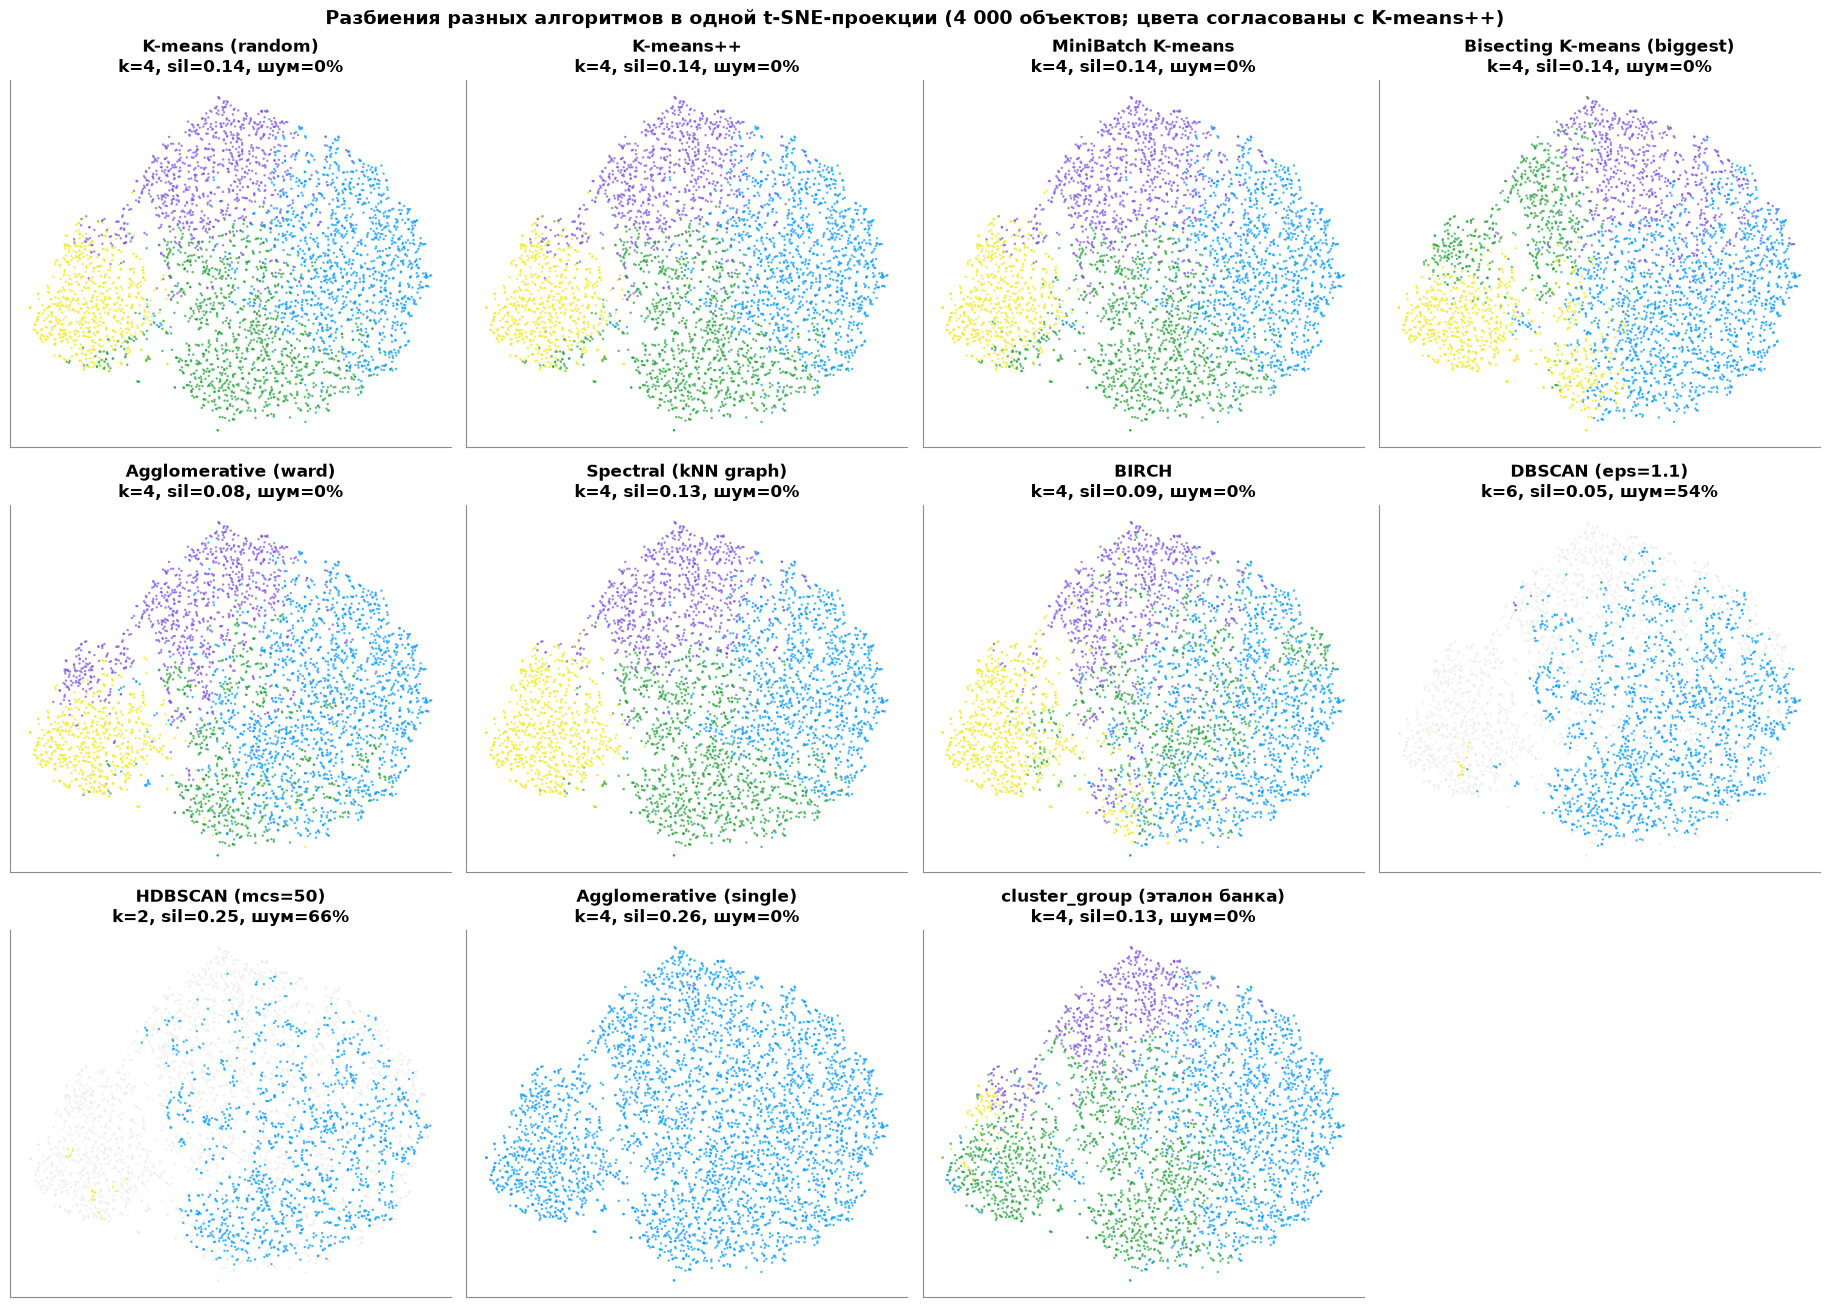

In [21]:
names_grid = ["K-means (random)", "K-means++", "MiniBatch K-means", "Bisecting K-means (biggest)",
              "Agglomerative (ward)", "Spectral (kNN graph)", "BIRCH",
              "DBSCAN (eps=1.1)", "HDBSCAN (mcs=50)", "Agglomerative (single)",
              "cluster_group (эталон банка)"]
fig = mplts.plot_algorithms_grid(names_grid, emb_tsne, reference="K-means++", labels_source=RESULTS)
fig.suptitle(
    "Разбиения разных алгоритмов в одной t-SNE-проекции (4 000 объектов; цвета согласованы с K-means++)", 
    fontsize=14, fontweight="bold", y=1.01
)
plt.show()

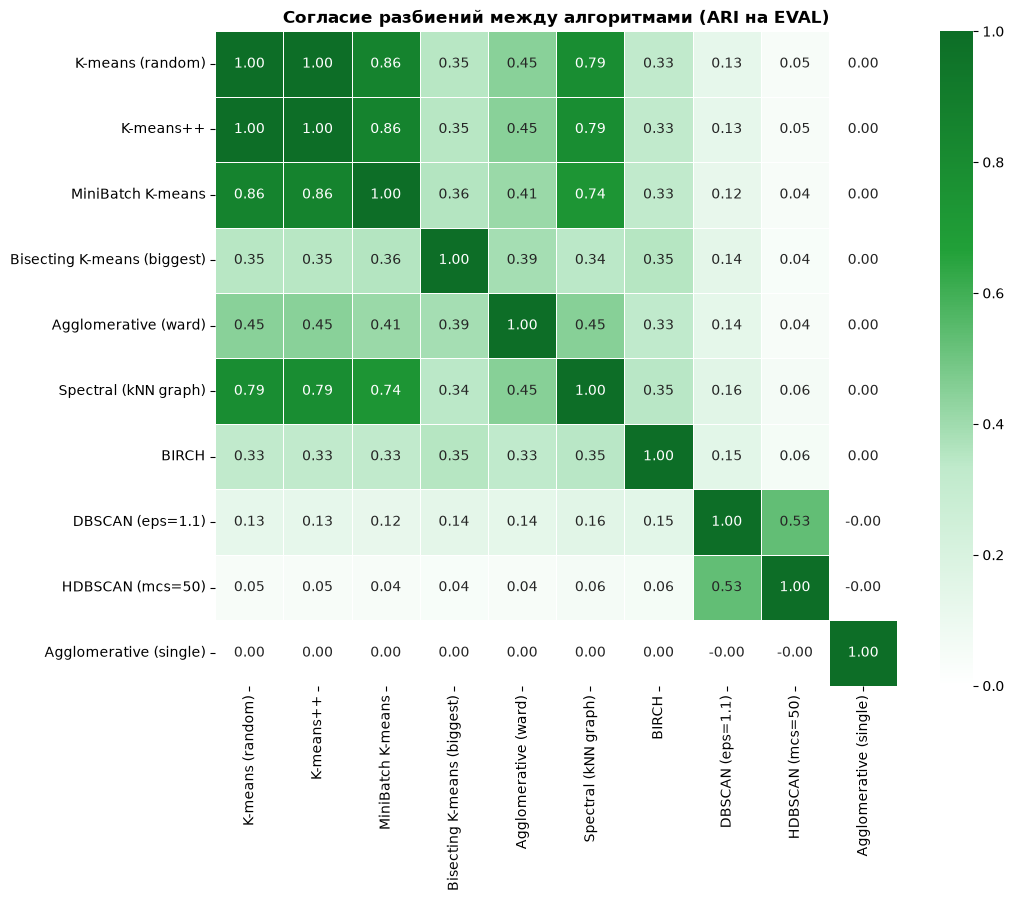

In [22]:
algos = [n for n in names_grid if n != "cluster_group (эталон банка)"]
ari_mat = pd.DataFrame(
    [
        [adjusted_rand_score(RESULTS[a]["labels"], RESULTS[b]["labels"]) for b in algos] 
        for a in algos
    ], index=algos, columns=algos
)
fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(
    ari_mat, annot=True, fmt=".2f", 
    cmap=SEQUENTIAL_CMAP, vmin=0, 
    vmax=1, ax=ax, linewidths=0.5, linecolor=WHITE
)
ax.grid(False)
ax.set_title("Согласие разбиений между алгоритмами (ARI на EVAL)")
plt.show()

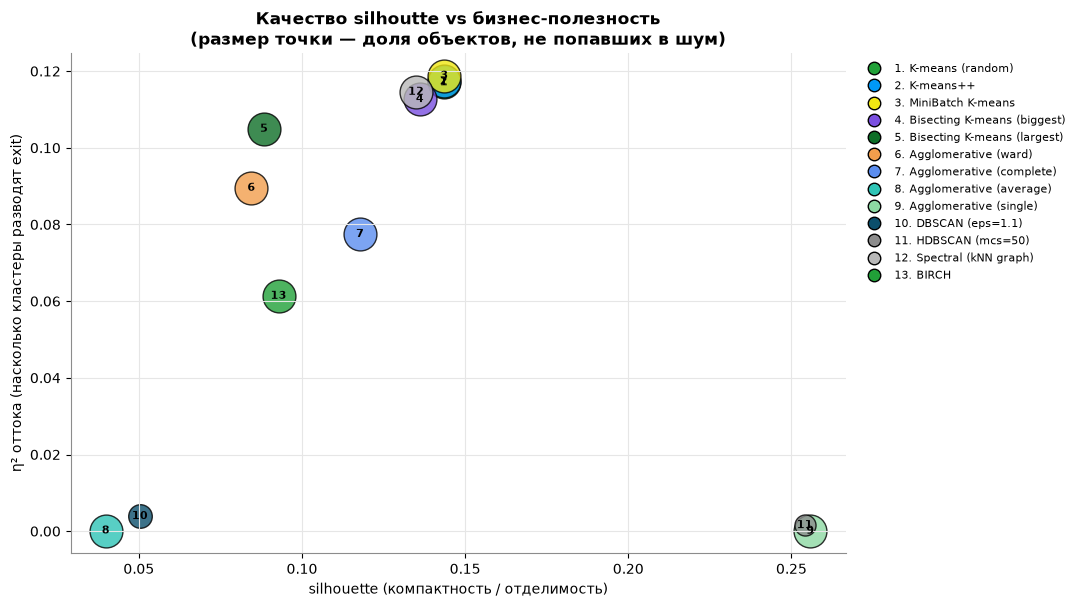

In [26]:
fig, ax = plt.subplots(figsize=(10, 6.5))
plot_df = summary.drop(index="cluster_group (эталон банка)")
plot_df = plot_df[plot_df["n_clusters"] >= 2]
handles = []
for i, (name, r) in enumerate(plot_df.iterrows()):
    color = CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)]
    ax.scatter(r["silhouette"], r["exit_eta2"], s=500 * (1 - r["noise_share"]) + 60,
               color=color, edgecolor="black", alpha=0.8)
    ax.text(r["silhouette"], r["exit_eta2"], str(i + 1), ha="center", va="center", fontsize=8, fontweight="bold")
    handles.append(plt.Line2D([0], [0], marker="o", ls="none", markerfacecolor=color, markeredgecolor="black",
                              markersize=9, label=f"{i + 1}. {name}"))
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_xlabel("silhouette (компактность / отделимость)")
ax.set_ylabel("η² оттока (насколько кластеры разводят exit)")
ax.set_title("Качество silhoutte vs бизнес-полезность\n(размер точки — доля объектов, не попавших в шум)")
plt.show()

### Выбор финальной модели

* **K-means++, K-means random, MiniBatch** и **спектральная кластеризация** дают близкие разбиения (попарный ARI 0.74–1.0) и лучшие значения сразу по двум осям: silhouette ≈ 0.14 и η² оттока ≈ 0.12.
  Совпадение результатов разных по природе алгоритмов (центроидного и графового) — признак того, что найденная структура
  реальна, а не артефакт конкретного метода.
* **Bisecting K-means, Ward и BIRCH** — промежуточные результаты (ARI с K-means++ всего 0.33–0.45); BIRCH с порогом 1.0 дробит данные на ~9.5 тыс. подкластеров и
  чувствителен к параметру `threshold`.
* **Плотностные методы** (DBSCAN, HDBSCAN) и **single/average linkage** не подходят для сегментации этих данных —
  они «видят» одно сплошное облако + выбросы. Высокий silhouette у `single` и HDBSCAN — ложный сигнал
  (у `single` один кластер содержит 99,9 % объектов, у HDBSCAN 66 % объектов исключены как шум).
* Готовая сегментация банка `cluster_group` в нашем пространстве имеет сопоставимый silhouette (≈ 0.13), но
  разделяет отток **вдвое хуже** (η² ≈ 0.05 против 0.12) — наша сегментация информативнее с точки зрения удержания.

**Финальная модель — K-means++ с k = 4**: лучшее сочетание silhouette и бизнес-полезности, высокая
устойчивость, линейное время на всей базе и естественное применение к новым клиентам через `predict` (ближайший
центроид). MiniBatch K-means даёт почти то же (ARI ≈ 0.87, inertia +0.2 %) и пригодится, если база вырастет на порядки.

## 10. Проверка на отложенной выборке и устойчивость

ARI(предсказание центроидами train, независимый K-means на test) = 0.977
Бутстреп (10 выборок с возвращением): ARI с финальной моделью на test = 0.972 ± 0.010


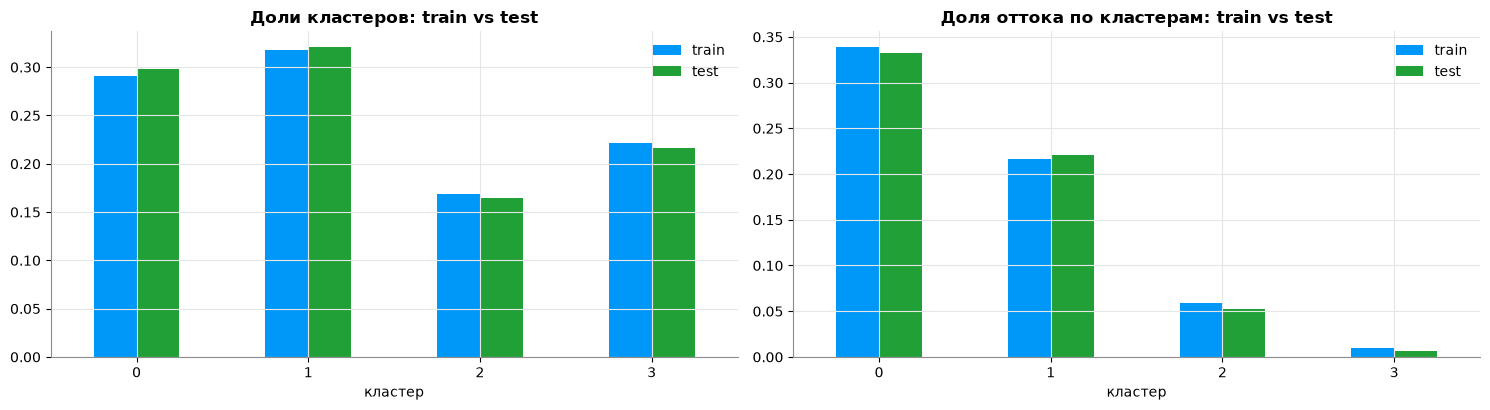

,silhouette,inertia_per_obj
train,0.1435,5.7694
test (центроиды train),0.1472,5.7457


In [28]:
test_pred = kmeans.predict(X_test)                          # центроиды с train -> новые клиенты
km_test = KMeans(
    n_clusters=K_FINAL, n_init=10, 
    random_state=RANDOM_STATE
).fit(X_test)  # независимое обучение на test
rng_t = np.random.default_rng(RANDOM_STATE)
idx_t = rng_t.choice(len(X_test), 6000, replace=False)

check = pd.DataFrame({
    "silhouette": [
        silhouette_score(X_eval, kmeans.labels_[IDX_EVAL]), 
        silhouette_score(X_test[idx_t], test_pred[idx_t])
    ],
    "inertia_per_obj": [kmeans.inertia_ / len(X), -kmeans.score(X_test) / len(X_test)],
}, index=["train", "test (центроиды train)"])
print(f"ARI(предсказание центроидами train, независимый K-means на test) = ", end='')
print(f"{adjusted_rand_score(test_pred, km_test.labels_):.3f}")

boot_labels = []
for b in range(10):
    idx = rng.choice(len(X), len(X), replace=True)
    boot_labels.append(KMeans(n_clusters=K_FINAL, n_init=3, random_state=100 + b).fit(X[idx]).predict(X_test))
boot_ari = [adjusted_rand_score(test_pred, bl) for bl in boot_labels]
print(f"Бутстреп (10 выборок с возвращением): ARI с финальной моделью на test = {np.mean(boot_ari):.3f} ± {np.std(boot_ari):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
share = pd.DataFrame({"train": pd.Series(kmeans.labels_).value_counts(normalize=True),
                      "test": pd.Series(test_pred).value_counts(normalize=True)}).sort_index()
share.plot.bar(ax=axes[0], color=[TRAIN_LINE, TEST_LINE], rot=0)
axes[0].set_title("Доли кластеров: train vs test"); axes[0].set_xlabel("кластер")
churn_cmp = pd.DataFrame({"train": train["exit"].groupby(kmeans.labels_).mean(),
                          "test": test["exit"].groupby(test_pred).mean()})
churn_cmp.plot.bar(ax=axes[1], color=[TRAIN_LINE, TEST_LINE], rot=0)
axes[1].set_title("Доля оттока по кластерам: train vs test")
axes[1].set_xlabel("кластер")
fig.tight_layout()
plt.show()
check.round(4)

Модель **обобщается**: silhouette и средняя inertia на test практически совпадают с train, доли кластеров
и доли оттока в них воспроизводятся. Независимо обученный на test K-means находит почти то же разбиение (ARI близок к 1),
бутстреп подтверждает устойчивость. Значит, сегменты — свойство генеральной совокупности клиентов, а не шум обучающей выборки.

## 11. Интерпретация кластеров

Для удобства перенумеруем кластеры по возрастанию медианного дохода и посмотрим на них с разных сторон.

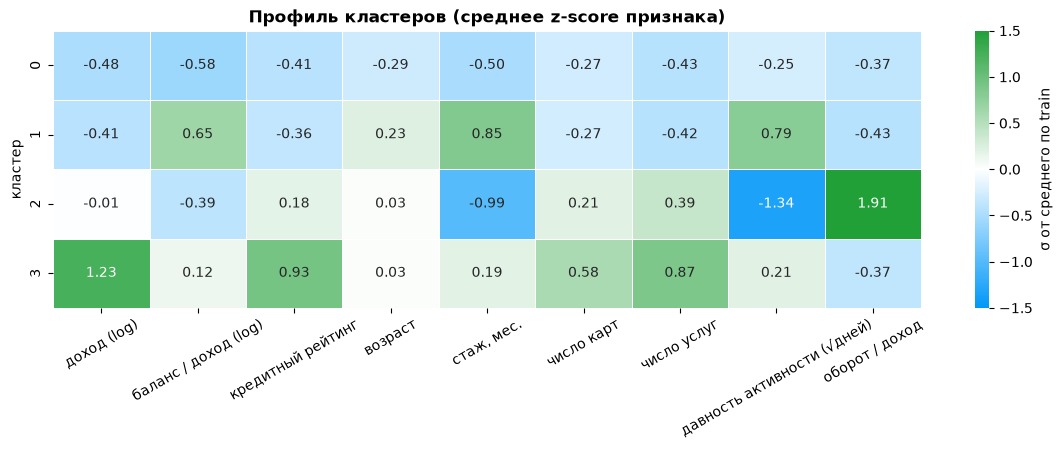

In [29]:
order = train.groupby(kmeans.labels_)["monthly_ir"].median().sort_values().index
remap = {old: new for new, old in enumerate(order)}
labels_final = np.vectorize(remap.get)(kmeans.labels_)
labels_test_final = np.vectorize(remap.get)(test_pred)
labels_vis_final = labels_final[IDX_VIS]
X_df = train[Z_COLS].set_axis(FEATURES, axis=1)

profile = mplts.cluster_profile(X_df, labels_final)
fig, ax = plt.subplots(figsize=(14, 3.6))
mplts.plot_profile_heatmap(profile, ax=ax)
plt.show()

In [30]:
MLN = 1e6
summary_tbl = train.assign(cl=labels_final).groupby("cl").agg(
    size=("id", "size"),
    доход_млн=("monthly_ir", lambda s: s.median() / MLN),
    баланс_млн=("balance", lambda s: s.median() / MLN),
    баланс_к_доходу=("raw_log_savings_ratio", lambda s: np.exp(s.median())),
    рейтинг=("credit_sco", "median"),
    возраст=("age", "median"),
    стаж_лет=("tenure_ye", "mean"),
    карт=("nums_card", "mean"),
    услуг=("nums_service", "mean"),
    активных=("active_member", "mean"),
    дней_без_активности=("recency_days", "median"),
    вовлечённость=("engagement_score", "mean"),
    риск=("risk_score", "mean"),
    отток=("exit", "mean"),
)
summary_tbl["доля"] = summary_tbl["size"] / len(train)
summary_tbl.round(2)

,size,доход_млн,баланс_млн,баланс_к_доходу,рейтинг,возраст,стаж_лет,карт,услуг,активных,дней_без_активности,вовлечённость,риск,отток,доля
cl,,,,,,,,,,,,,,,
0,18646,17.0,14.49,0.85,664.0,43.0,1.09,2.30,2.71,0.09,229.0,20.93,0.33,0.34,0.29
1,20349,18.0,35.60,1.96,666.0,51.0,2.89,2.31,2.71,0.01,672.0,17.75,0.32,0.22,0.32
2,10830,24.0,23.68,0.94,692.0,48.0,0.58,2.89,4.35,1.00,33.5,74.98,0.17,0.06,0.17
3,14175,82.0,102.80,1.36,732.0,48.0,2.00,3.34,5.32,0.07,378.0,33.18,0.19,0.01,0.22


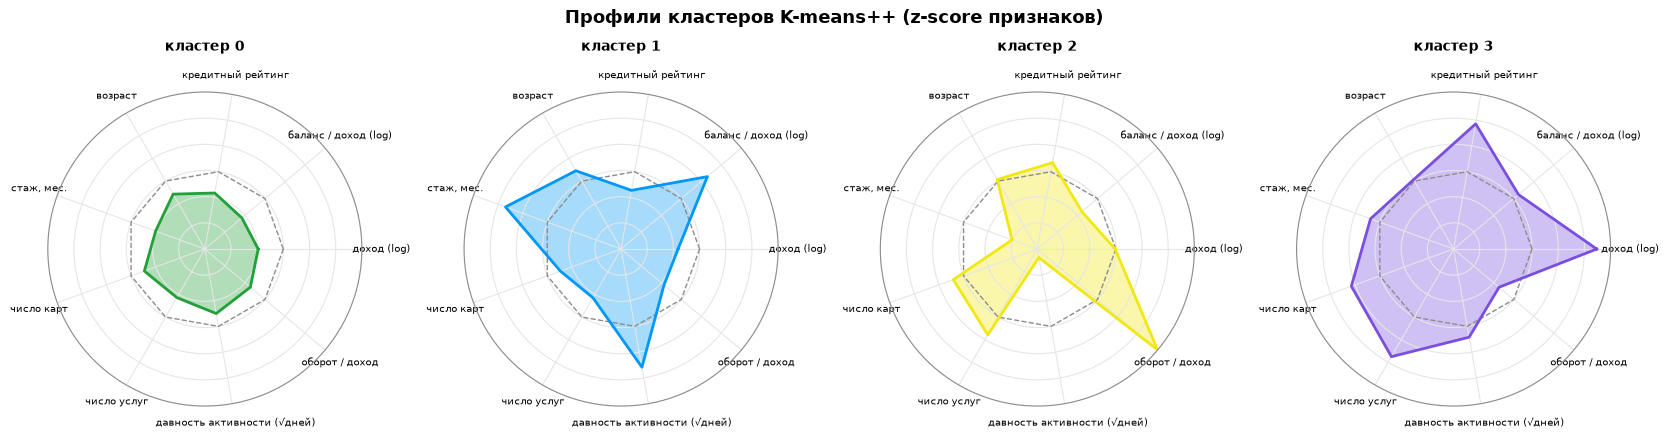

In [31]:
fig = mplts.plot_radar(
    profile, 
    title="Профили кластеров K-means++ (z-score признаков)"
)
plt.show()

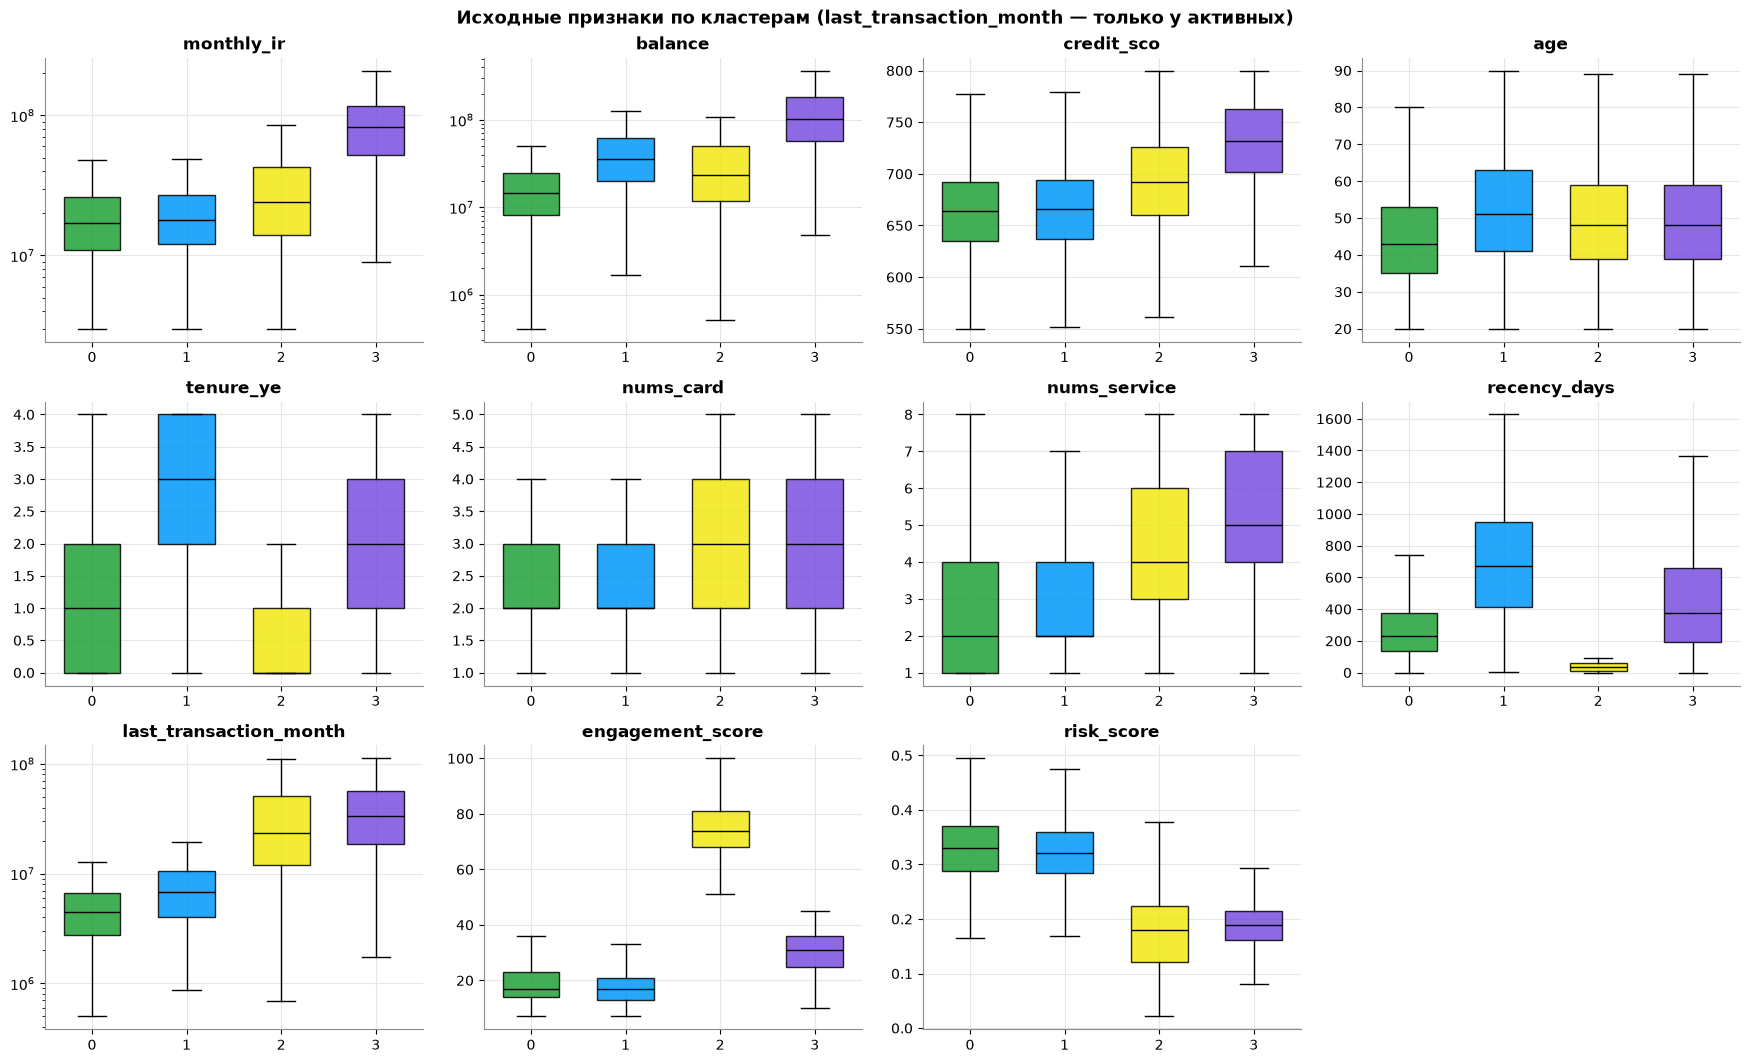

In [32]:
num_cols = ["monthly_ir", "balance", "credit_sco", "age", "tenure_ye", "nums_card", "nums_service",
            "recency_days", "last_transaction_month", "engagement_score", "risk_score"]
meta_pos = train.copy()
meta_pos["last_transaction_month"] = meta_pos["last_transaction_month"].replace(0, np.nan)
fig = mplts.plot_numeric_by_cluster(
    meta_pos, labels_final, 
    num_cols, log_cols=("monthly_ir", "balance", "last_transaction_month"),
    title="Исходные признаки по кластерам (last_transaction_month — только у активных)"
)
plt.show()

На основе профилей (таблица, тепловая карта, радар и боксплоты) даём кластерам имена:

| # | Название | Доля | Портрет | Отток |
|---|---|---|---|---|
| 0 | **Уходящие новички** | 29 % | массовый доход (~17 млн VND), стаж ≈ 1 год, самые молодые (медиана 43), мало продуктов (2 услуги), на счёте меньше месячного дохода; почти все перестали пользоваться банком (активны 9 %, медиана давности ~230 дней) | **34 %** |
| 1 | **Спящие вкладчики** | 32 % | такой же массовый доход, но стаж ≈ 3 года, старше (медиана 51), держат на счёте ~2 месячных дохода; неактивны давно (медиана ~670 дней), вовлечённость минимальна | 22 % |
| 2 | **Активные цифровые** | 17 % | 100 % активны (мобильный канал, давность ~1 мес.), оборот за месяц ≈ месячному доходу, больше услуг (4+), вовлечённость ~75; в основном новые клиенты (стаж < 1 года) | 6 % |
| 3 | **Состоятельные** | 22 % | доход ~82 млн VND, баланс ~100 млн, рейтинг ~730, больше всего продуктов (5+ услуг, 3+ карты); при этом в основном неактивны в каналах — банк им нужен как «хранилище» | **1 %** |

Главные оси разбиения: **активность** (кластер 2 против остальных), **доход** (кластер 3 против массовых) и
**стаж** (кластеры 0 и 1 — один и тот же массовый клиент на разных этапах жизненного цикла).

In [33]:
CLUSTER_NAMES = {
    0: "Уходящие новички",
    1: "Спящие вкладчики",
    2: "Активные цифровые",
    3: "Состоятельные",
}
pd.DataFrame({
    "название": CLUSTER_NAMES, 
    "доля": pd.Series(labels_final).value_counts(normalize=True).sort_index().round(3),
    "отток": train["exit"].groupby(labels_final).mean().round(3)
})

,название,доля,отток
0,Уходящие новички,0.291,0.339
1,Спящие вкладчики,0.318,0.217
2,Активные цифровые,0.169,0.059
3,Состоятельные,0.221,0.010


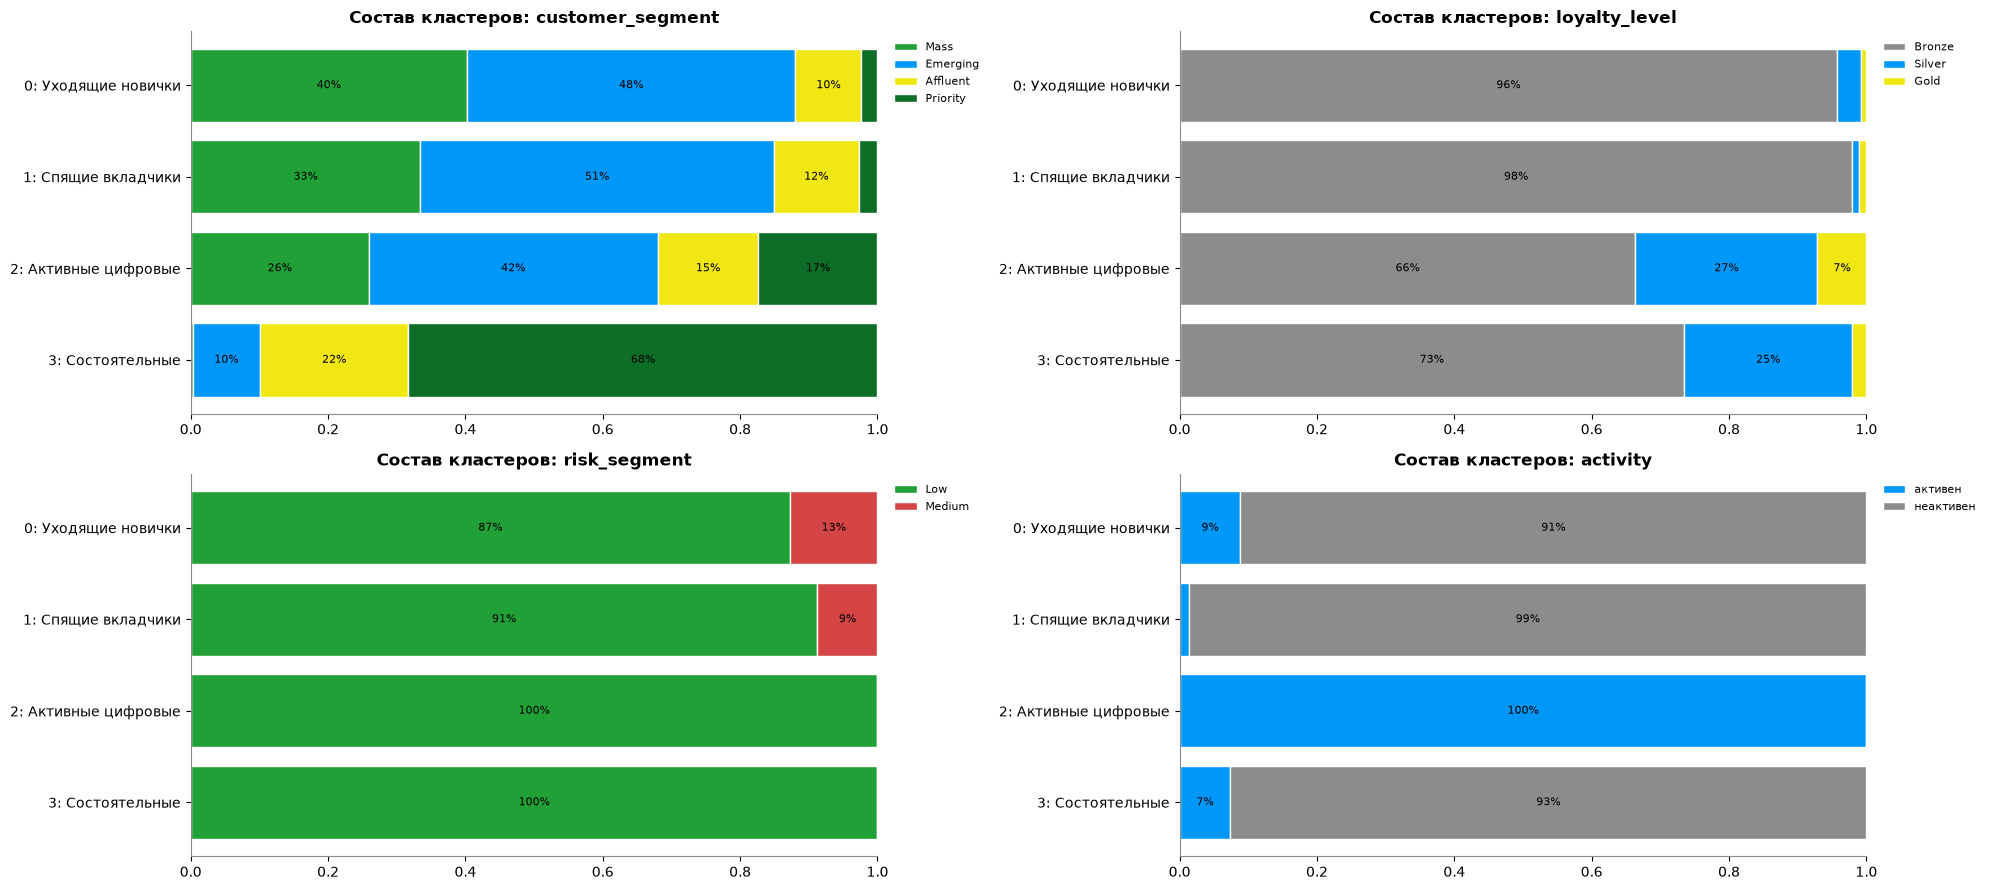

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(20, 9))
mplts.plot_categorical_by_cluster(
    train, labels_final, "customer_segment", 
    order=["Mass", "Emerging", "Affluent", "Priority"],
    ax=axes[0, 0], names=CLUSTER_NAMES)
mplts.plot_categorical_by_cluster(
    train, labels_final, "loyalty_level", order=["Bronze", "Silver", "Gold"],
    ax=axes[0, 1], names=CLUSTER_NAMES, palette=[GRAY, BLUE, YELLOW]
)
mplts.plot_categorical_by_cluster(
    train, labels_final, "risk_segment", order=["Low", "Medium"], ax=axes[1, 0],
    names=CLUSTER_NAMES, palette=[GREEN, CHURN_COLOR]
)
mplts.plot_categorical_by_cluster(
    train.assign(activity=train["active_member"].map({1: "активен", 0: "неактивен"})),
    labels_final, "activity", order=["активен", "неактивен"], ax=axes[1, 1],
    names=CLUSTER_NAMES, palette=[BLUE, GRAY]
)
fig.tight_layout()
plt.show()

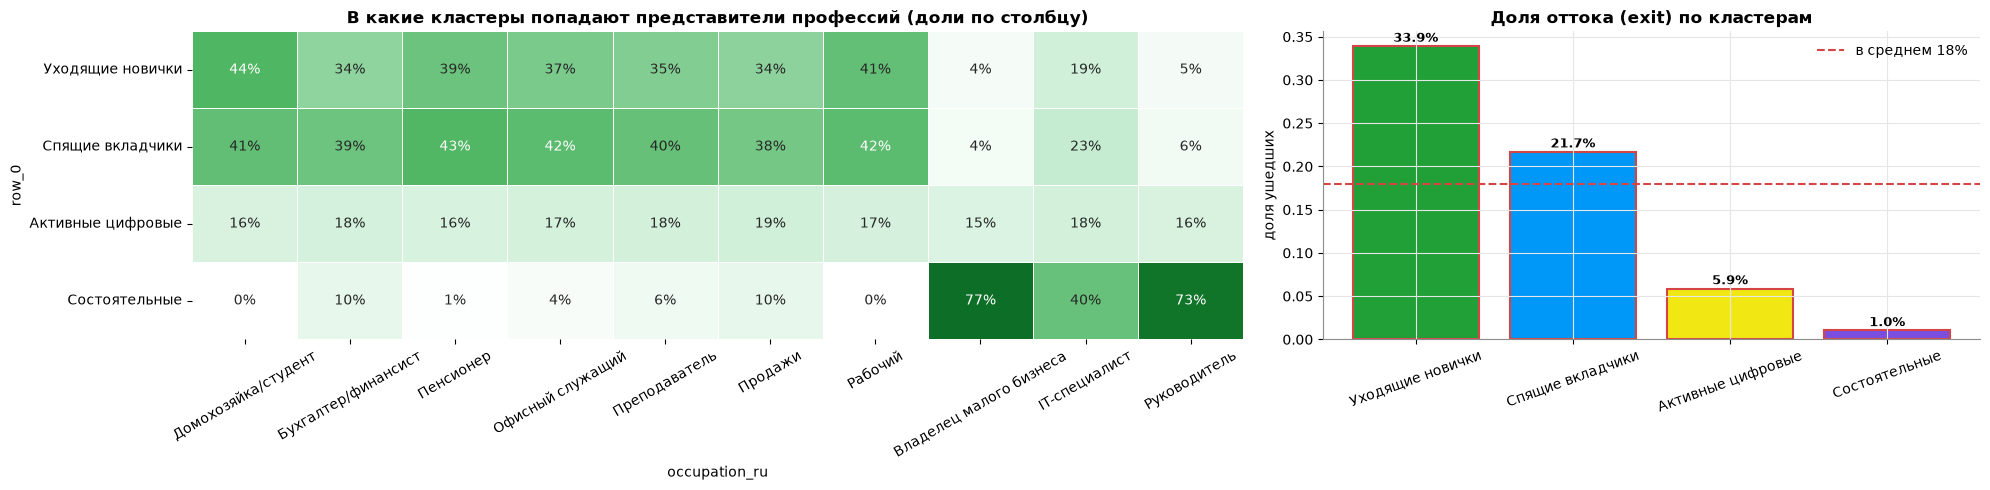

In [35]:
occ = pd.crosstab(labels_final, train["occupation_ru"], normalize="columns")
occ = occ[occ.idxmax().sort_values().index]
fig, axes = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={"width_ratios": [1.6, 1]})
sns.heatmap(occ.rename(index=CLUSTER_NAMES), annot=True, fmt=".0%", cmap=SEQUENTIAL_CMAP, ax=axes[0], cbar=False,
            linewidths=0.5, linecolor=WHITE)
axes[0].grid(False)
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("В какие кластеры попадают представители профессий (доли по столбцу)")
mplts.plot_churn_by_cluster(train, labels_final, ax=axes[1], names=CLUSTER_NAMES)
fig.tight_layout()
plt.show()

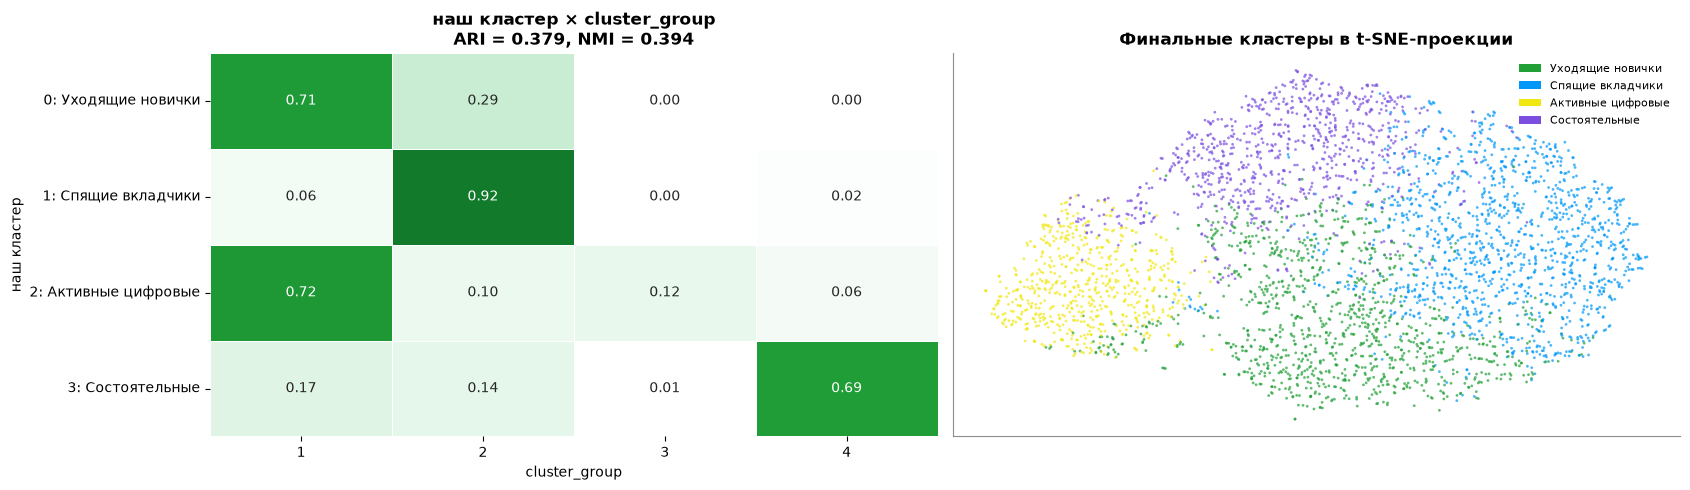

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
mplts.plot_crosstab(
    labels_final, train["cluster_group"].to_numpy(), 
    "наш кластер", "cluster_group", ax=axes[0]
)
axes[0].set_yticklabels([f"{i}: {CLUSTER_NAMES[i]}" for i in range(K_FINAL)], rotation=0)
mplts.plot_embedding(
    emb_tsne, labels_vis_final, ax=axes[1], 
    names=CLUSTER_NAMES, title="Финальные кластеры в t-SNE-проекции"
)
fig.tight_layout()
plt.show()

### Правила, описывающие кластеры

Обучим неглубокое дерево решений предсказывать номер кластера по **исходным** (не масштабированным) признакам —
получим понятные правила вида «если доход > X и …, то кластер N». Точность дерева показывает, насколько кластеры
описываются простыми порогами.

Точность дерева глубины 3: 79.2%

|--- tn_to_income_ratio <= 0.3
|   |--- income_mln <= 43.5
|   |   |--- tenure_ye <= 1.5
|   |   |   |--- class: 0
|   |   |--- tenure_ye >  1.5
|   |   |   |--- class: 1
|   |--- income_mln >  43.5
|   |   |--- credit_sco <= 688.5
|   |   |   |--- class: 3
|   |   |--- credit_sco >  688.5
|   |   |   |--- class: 3
|--- tn_to_income_ratio >  0.3
|   |--- tn_to_income_ratio <= 0.6
|   |   |--- income_mln <= 55.5
|   |   |   |--- class: 2
|   |   |--- income_mln >  55.5
|   |   |   |--- class: 3
|   |--- tn_to_income_ratio >  0.6
|   |   |--- tenure_ye <= 2.5
|   |   |   |--- class: 2
|   |   |--- tenure_ye >  2.5
|   |   |   |--- class: 2



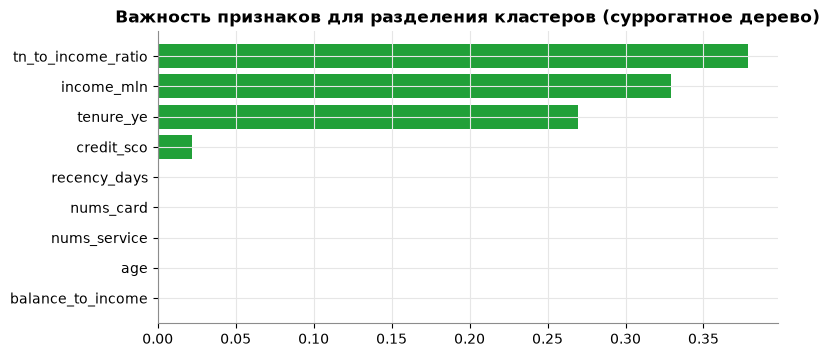

In [41]:
rule_df = train.assign(
    income_mln=train["monthly_ir"] / MLN,
    balance_to_income=np.exp(train["raw_log_savings_ratio"]),
    tn_to_income_ratio=np.expm1(train["raw_tn_to_income"]),
)
rule_cols = ["income_mln", "balance_to_income", "credit_sco", "age", "tenure_ye", "nums_card", "nums_service",
             "recency_days", "tn_to_income_ratio"]
tree, acc, rules = mplts.surrogate_tree(
    rule_df, labels_final, rule_cols, max_depth=3, 
    min_samples_leaf=200, random_state=RANDOM_STATE
)
print(f"Точность дерева глубины 3: {acc:.1%}\n")
print(rules)
imp = pd.Series(tree.feature_importances_, index=rule_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(imp.index, imp.values, color=GREEN)
ax.set_title("Важность признаков для разделения кластеров (суррогатное дерево)")
plt.show()

**Правила суррогатного дерева** повторяют интерпретацию и дают готовую бизнес-логику присвоения сегмента
(≈ 80 % совпадения с K-means при глубине всего 3):

* оборот за месяц > 0.3 месячного дохода → **Активные цифровые** (кроме очень богатых — они уходят в «Состоятельные»);
* неактивен и доход > ~44 млн VND → **Состоятельные**;
* неактивен, доход ниже и стаж ≤ 1 года → **Уходящие новички**, стаж ≥ 2 лет → **Спящие вкладчики**.

Сравнение с `cluster_group`: «Спящие вкладчики» на 92 % — это группа 2 банка, «Состоятельные» на 69 % — группа 4.
Группу 1 банка мы делим на две части с очень разным риском: активных клиентов («Активные цифровые», отток 6 %) и
угасающих новичков («Уходящие новички», отток 34 %). Отсюда вдвое лучшее разделение оттока.

## 12. Выводы

**Об алгоритмах.**
* В данных нет естественных плотных групп — это сплошное облако с плавно меняющейся плотностью. Поэтому плотностные
  методы (DBSCAN, HDBSCAN) и `single`/`average` linkage не дают полезной сегментации; их высокий silhouette — артефакт
  вырожденных разбиений.
* Разбивающие методы дают содержательную **сегментацию континуума**. Лучший результат — **K-means++, k = 4**: лучший
  баланс silhouette и разделения оттока, устойчивость (бутстреп ARI ≈ 0.98), подтверждение на test (ARI ≈ 0.98).
  Спектральная кластеризация независимо находит почти то же разбиение (ARI ≈ 0.79).
* K-means++ и случайная инициализация на этих данных сходятся к одному решению, но K-means++ делает это стабильнее.
  MiniBatch K-means — почти бесплатная замена при росте данных. Bisecting K-means, GMM, Ward и BIRCH дают разбиения,
  согласующиеся с K-means лишь частично (ARI 0.33–0.45), и хуже разделяют отток.

**О клиентах и рекомендации.**
* **Уходящие новички** (29 %, отток 34 %) — главный приоритет удержания: онбординг в первый год, подключение
  мобильного банка и второго продукта; именно у этого сегмента активность «гаснет» раньше всего.
* **Спящие вкладчики** (32 %, отток 22 %) — деньги держат, но банком не пользуются: реактивационные кампании,
  депозитные и накопительные продукты под их «подушку».
* **Активные цифровые** (17 %, отток 6 %) — ядро вовлечённой базы: кросс-продажи, развитие digital-сервисов.
* **Состоятельные** (22 %, отток 1 %) — лояльны и многопродуктовы: персональное обслуживание и инвестиционные продукты,
  здесь ценен рост дохода с клиента, а не удержание.

In [42]:
out = pd.DataFrame({"id": np.r_[train["id"], test["id"]],
                    "cluster": np.r_[labels_final, labels_test_final],
                    "cluster_name": [CLUSTER_NAMES[c] for c in np.r_[labels_final, labels_test_final]],
                    "split": ["train"] * len(train) + ["test"] * len(test)})
out.to_csv(DATA_DIR / "clusters_kmeans.csv", index=False)
print("Метки сохранены в", DATA_DIR / "clusters_kmeans.csv", out.shape)
out.groupby(["cluster", "cluster_name"])["split"].value_counts().unstack()

Метки сохранены в data/processed/clusters_kmeans.csv (80000, 4)


,split,test,train
cluster,cluster_name,,
0,Уходящие новички,4770,18646
1,Спящие вкладчики,5137,20349
2,Активные цифровые,2626,10830
3,Состоятельные,3467,14175
